# Electricity Consumption in Spain

## Exploratory Data Analysis, Municipality Analysis and Clustering

This notebook follows the data from the moment we first open it to the final municipality clusters.

The approach is deliberately exploratory:

**explore → understand → inspect → clean → analyse → engineer features → cluster → interpret**

The main analysis uses **Table A**. The other supplied files are kept untouched and are not required for the main analysis.

The central questions are:

- Which municipalities have the highest total electricity consumption?
- How does electricity consumption differ between municipalities?
- Can municipalities be grouped into meaningful clusters based on their consumption characteristics?

## Setup

We use Polars because Table A is large. Lazy Parquet scanning allows us to work with the data without loading all 16 million records into memory at once.

In [2]:
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

print("Polars:", pl.__version__)

Polars: 1.44.2


In [3]:
# Project root
PROJECT_ROOT = Path.cwd().parent

# Data directories
MAIN_DATA_DIR = PROJECT_ROOT / "export" / "main_parquet"
METADATA_DIR = PROJECT_ROOT / "export" / "small_parquet"
print("Project root:")
print(PROJECT_ROOT)

print("\nMain data directory:")
print(MAIN_DATA_DIR)

print("\nMetadata directory:")
print(METADATA_DIR)

Project root:
e:\tasks\spain_elec

Main data directory:
e:\tasks\spain_elec\export\main_parquet

Metadata directory:
e:\tasks\spain_elec\export\small_parquet


In [4]:
A_PATH = PROJECT_ROOT / "data" / "a.parquet"

if not A_PATH.exists():
    raise FileNotFoundError(
        f"Could not find Table A at: {A_PATH}\n"
        "Make sure the notebook is inside the EDA folder."
    )

# Keep Table A lazy throughout the main analysis.
A_raw = pl.scan_parquet(str(A_PATH))

print("Table A found:", A_PATH)
print("Table A is being read lazily.")

Table A found: e:\tasks\spain_elec\data\a.parquet
Table A is being read lazily.


## Exploring the raw dataset

Before making any assumptions about the variables, I want to see the basic shape of the data: how large it is, what columns exist, and what a few records look like.

In [5]:
raw_schema = A_raw.collect_schema()

A_rows = (
    A_raw
    .select(pl.len())
    .collect()
    .item()
)

print(f"Rows: {A_rows:,}")
print(f"Columns: {len(raw_schema.names())}")

Rows: 16,155,725
Columns: 83


In [6]:
schema_table = pl.DataFrame({
    "column": raw_schema.names(),
    "dtype": [str(dtype) for dtype in raw_schema.dtypes()],
})

schema_table

column,dtype
str,str
"""DIA""","""String"""
"""H1""","""Int32"""
"""ACTIVA_H1""","""Int32"""
"""REACTIVA_H1""","""Int32"""
"""H2""","""Int32"""
…,…
"""TARGET_TENENCIA_CUPS""","""String"""
"""IDENTIFICADOR""","""Int64"""
"""CNAE""","""String"""


In [7]:
A_raw.head(5).collect()

DIA,H1,ACTIVA_H1,REACTIVA_H1,H2,ACTIVA_H2,REACTIVA_H2,H3,ACTIVA_H3,REACTIVA_H3,H4,ACTIVA_H4,REACTIVA_H4,H5,ACTIVA_H5,REACTIVA_H5,H6,ACTIVA_H6,REACTIVA_H6,H7,ACTIVA_H7,REACTIVA_H7,H8,ACTIVA_H8,REACTIVA_H8,H9,ACTIVA_H9,REACTIVA_H9,H10,ACTIVA_H10,REACTIVA_H10,H11,ACTIVA_H11,REACTIVA_H11,H12,ACTIVA_H12,REACTIVA_H12,…,H16,ACTIVA_H16,REACTIVA_H16,H17,ACTIVA_H17,REACTIVA_H17,H18,ACTIVA_H18,REACTIVA_H18,H19,ACTIVA_H19,REACTIVA_H19,H20,ACTIVA_H20,REACTIVA_H20,H21,ACTIVA_H21,REACTIVA_H21,H22,ACTIVA_H22,REACTIVA_H22,H23,ACTIVA_H23,REACTIVA_H23,H24,ACTIVA_H24,REACTIVA_H24,H25,ACTIVA_H25,REACTIVA_H25,DE_MUNICIP,FECHA_ALTA_STRO,TARGET_TENENCIA_CUPS,IDENTIFICADOR,CNAE,PRODUCTO,MERCADO
str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,str,i64,str,str,str
"""20150624""",1,280,0,2,228,0,3,172,0,4,196,0,5,287,0,6,195,0,7,223,0,8,254,0,9,274,0,10,404,0,11,333,0,12,1106,0,…,16,262,0,17,300,0,18,326,0,19,281,0,20,357,0,21,448,0,22,349,0,23,501,0,24,383,0,25,0,0,"""UBRIQUE""","""Q11989""","""0.127242""",26785,"""T1""","""P1""","""M1"""
"""20150913""",1,142,0,2,61,0,3,67,0,4,64,0,5,64,0,6,70,0,7,126,0,8,101,0,9,40,0,10,179,0,11,131,0,12,169,0,…,16,90,0,17,50,0,18,87,0,19,48,0,20,130,0,21,366,0,22,302,0,23,133,0,24,81,0,25,0,0,"""SANTA COLOMA DE GRAMENET""","""Q31979""","""0.000000""",86782,"""T1""","""P13""","""M2"""
"""20150710""",1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,16,0,0,17,0,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""VALVERDE""","""Q12010""","""0.000000""",75439,"""T1""","""P14""","""M2"""
"""20150517""",1,186,0,2,129,0,3,176,0,4,123,0,5,183,0,6,200,0,7,185,0,8,170,0,9,161,0,10,409,0,11,399,0,12,351,0,…,16,422,0,17,321,0,18,330,0,19,346,0,20,329,0,21,348,0,22,345,0,23,142,0,24,236,0,25,0,0,"""CAZORLA""","""Q31989""","""0.000000""",43916,"""T1""","""P1""","""M1"""
"""20141108""",1,48,0,2,86,0,3,115,0,4,50,0,5,48,0,6,108,0,7,119,0,8,59,0,9,59,0,10,106,0,11,113,0,12,59,0,…,16,112,0,17,65,0,18,681,0,19,731,0,20,493,0,21,466,0,22,231,0,23,67,0,24,67,0,25,0,0,"""HUELVA""","""Q31989""","""0.011962""",18260,"""T1""","""P1""","""M1"""


The first look shows a wide dataset: each record contains the date, a set of time-position variables, active and reactive electricity measurements, and customer/geographical characteristics.

At this stage I am not treating repeated records or missing values as errors. I first want to understand what one observation represents.

## Making the column names easier to work with

The original column names are useful for tracing the data back to its source, but English names make the analysis easier to read.

The raw Parquet file is **not modified**. The renaming happens only in the LazyFrame used by this notebook.

In [8]:
column_mapping = {
    "DIA": "DATE",
    "DE_MUNICIP": "MUNICIPALITY",
    "FECHA_ALTA_STRO": "SUPPLY_REGISTRATION_PERIOD",
    "TARGET_TENENCIA_CUPS": "GAS_DISTRIBUTION_PROBABILITY",
    "IDENTIFICADOR": "CUSTOMER_ID",
    "CNAE": "CUSTOMER_TYPE",
    "PRODUCTO": "ELECTRICITY_PRODUCT",
    "MERCADO": "MARKET",
}

for i in range(1, 26):
    column_mapping[f"H{i}"] = f"TIME_H{i}"
    column_mapping[f"ACTIVA_H{i}"] = f"ACTIVE_H{i}"
    column_mapping[f"REACTIVA_H{i}"] = f"REACTIVE_H{i}"

A = A_raw.rename(column_mapping)

print("Columns after renaming:")
print(A.collect_schema().names())

Columns after renaming:
['DATE', 'TIME_H1', 'ACTIVE_H1', 'REACTIVE_H1', 'TIME_H2', 'ACTIVE_H2', 'REACTIVE_H2', 'TIME_H3', 'ACTIVE_H3', 'REACTIVE_H3', 'TIME_H4', 'ACTIVE_H4', 'REACTIVE_H4', 'TIME_H5', 'ACTIVE_H5', 'REACTIVE_H5', 'TIME_H6', 'ACTIVE_H6', 'REACTIVE_H6', 'TIME_H7', 'ACTIVE_H7', 'REACTIVE_H7', 'TIME_H8', 'ACTIVE_H8', 'REACTIVE_H8', 'TIME_H9', 'ACTIVE_H9', 'REACTIVE_H9', 'TIME_H10', 'ACTIVE_H10', 'REACTIVE_H10', 'TIME_H11', 'ACTIVE_H11', 'REACTIVE_H11', 'TIME_H12', 'ACTIVE_H12', 'REACTIVE_H12', 'TIME_H13', 'ACTIVE_H13', 'REACTIVE_H13', 'TIME_H14', 'ACTIVE_H14', 'REACTIVE_H14', 'TIME_H15', 'ACTIVE_H15', 'REACTIVE_H15', 'TIME_H16', 'ACTIVE_H16', 'REACTIVE_H16', 'TIME_H17', 'ACTIVE_H17', 'REACTIVE_H17', 'TIME_H18', 'ACTIVE_H18', 'REACTIVE_H18', 'TIME_H19', 'ACTIVE_H19', 'REACTIVE_H19', 'TIME_H20', 'ACTIVE_H20', 'REACTIVE_H20', 'TIME_H21', 'ACTIVE_H21', 'REACTIVE_H21', 'TIME_H22', 'ACTIVE_H22', 'REACTIVE_H22', 'TIME_H23', 'ACTIVE_H23', 'REACTIVE_H23', 'TIME_H24', 'ACTIVE_H24', 'R

In [9]:
schema_table = pl.DataFrame({
    "column": A.collect_schema().names(),
    "dtype": [str(dtype) for dtype in raw_schema.dtypes()],
})

schema_table

column,dtype
str,str
"""DATE""","""String"""
"""TIME_H1""","""Int32"""
"""ACTIVE_H1""","""Int32"""
"""REACTIVE_H1""","""Int32"""
"""TIME_H2""","""Int32"""
…,…
"""GAS_DISTRIBUTION_PROBABILITY""","""String"""
"""CUSTOMER_ID""","""Int64"""
"""CUSTOMER_TYPE""","""String"""


In [10]:
A = A.with_columns(
    pl.col("GAS_DISTRIBUTION_PROBABILITY").cast(pl.Float32, strict=False)
)

In [11]:
A.collect_schema()["GAS_DISTRIBUTION_PROBABILITY"]

Float32

The measurement groups now have a consistent naming scheme:

- `ACTIVE_H1` to `ACTIVE_H25` → active electricity measurements
- `REACTIVE_H1` to `REACTIVE_H25` → reactive electricity measurements
- `TIME_H1` to `TIME_H25` → time-position variables

The customer and descriptive fields have also been renamed to make the later analysis more readable.

## Understanding the date

The date is currently stored as text. Before doing anything time-related, I will check its range, number of distinct dates, and whether any values fail to convert to a real date.

In [12]:
date_overview = (
    A.select(
        pl.col("DATE").min().alias("first_date_text"),
        pl.col("DATE").max().alias("last_date_text"),
        pl.col("DATE").n_unique().alias("unique_dates"),
        pl.col("DATE").null_count().alias("missing_date_values"),
    )
    .collect()
)

date_overview

first_date_text,last_date_text,unique_dates,missing_date_values
str,str,u32,u32
"""20130913""","""20151019""",727,0


In [13]:
A = A.with_columns(
    pl.col("DATE")
    .str.strptime(
        pl.Date,
        format="%Y%m%d",
        strict=False
    )
    .alias("DATE")
)

date_quality = (
    A.select(
        pl.col("DATE").min().alias("first_date"),
        pl.col("DATE").max().alias("last_date"),
        pl.col("DATE").n_unique().alias("unique_dates"),
        pl.col("DATE").null_count().alias("invalid_or_missing_dates"),
    )
    .collect()
)

date_quality

first_date,last_date,unique_dates,invalid_or_missing_dates
date,date,u32,u32
2013-09-13,2015-10-19,727,0


The converted date will be used throughout the rest of the notebook. Keeping it as a proper date type avoids string-based mistakes when grouping observations by month, year, or season.

## Looking at the time-position variables

There are 25 variables named `TIME_H1` to `TIME_H25`. The documentation associated with the dataset describes the original H1–H25 fields as the hour/time positions within the day.

Rather than simply accepting that description, I will look at the values actually present in Table A.

In [14]:
time_cols = [f"TIME_H{i}" for i in range(1, 26)]

time_unique_counts = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in time_cols
    ])
    .collect()
)

time_unique_counts

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2


In [15]:
A.select(time_cols).head(3).collect()

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25


In [16]:
A.select([
    pl.col(c).null_count().alias(c)
    for c in time_cols
]).collect()

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


The H variables are treated as time-position information rather than electricity measurements. The actual energy values are stored separately in the ACTIVE and REACTIVE groups.

## Looking at active electricity consumption

Active consumption is the main measurement for this project. I will first inspect the individual hourly columns before creating a total daily measure.

At this stage, missing values are being **observed, not automatically deleted or replaced**.

In [17]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]
reactive_cols = [f"REACTIVE_H{i}" for i in range(1, 26)]

active_stats = []

for c in active_cols:
    row = (
        A.select([
            pl.col(c).count().alias("non_null"),
            pl.col(c).null_count().alias("nulls"),
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    active_stats.append({
        "column": c,
        "non_null": row[0],
        "nulls": row[1],
        "minimum": row[2],
        "maximum": row[3],
        "mean": row[4],
        "median": row[5],
    })

active_stats_df = pl.DataFrame(active_stats)
active_stats_df

column,non_null,nulls,minimum,maximum,mean,median
str,i64,i64,i64,i64,f64,f64
"""ACTIVE_H1""",16155725,0,-712,139194,271.243321,137.0
"""ACTIVE_H2""",16155725,0,-859,129014,219.068148,108.0
"""ACTIVE_H3""",16155725,0,-601,119181,190.031008,96.0
"""ACTIVE_H4""",16155725,0,-787,112334,175.119921,90.0
"""ACTIVE_H5""",16155725,0,-511,110510,169.011393,88.0
…,…,…,…,…,…,…
"""ACTIVE_H21""",16155725,0,-834,150367,407.396173,202.0
"""ACTIVE_H22""",16155725,0,-807,154261,435.502091,233.0
"""ACTIVE_H23""",16155725,0,-950,137113,407.42143,223.0


A useful first observation is whether missingness is concentrated in particular time positions. This matters later because a missing hourly measurement should not automatically be interpreted as a zero measurement.

In [18]:
active_null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in active_cols
    ])
    .collect()
)

active_null_summary

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24,ACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Looking at reactive consumption

Reactive energy is useful as supporting information, but active energy remains the main measure for the municipality ranking and clustering.

One issue already visible in the supplied data is that reactive values can contain many nulls. I will keep those original nulls rather than changing the raw measurements.

In [19]:
reactive_null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in reactive_cols
    ])
    .collect()
)

reactive_null_summary

REACTIVE_H1,REACTIVE_H2,REACTIVE_H3,REACTIVE_H4,REACTIVE_H5,REACTIVE_H6,REACTIVE_H7,REACTIVE_H8,REACTIVE_H9,REACTIVE_H10,REACTIVE_H11,REACTIVE_H12,REACTIVE_H13,REACTIVE_H14,REACTIVE_H15,REACTIVE_H16,REACTIVE_H17,REACTIVE_H18,REACTIVE_H19,REACTIVE_H20,REACTIVE_H21,REACTIVE_H22,REACTIVE_H23,REACTIVE_H24,REACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Understanding customers and municipalities

Now I want to understand the observational units. In particular, I want to know how many customers and municipalities are represented and whether the basic identifying fields contain missing values.

In [20]:
customer_geo_overview = (
    A.select([
        pl.col("CUSTOMER_ID").n_unique().alias("unique_customers"),
        pl.col("CUSTOMER_ID").null_count().alias("missing_customer_ids"),
        pl.col("MUNICIPALITY").n_unique().alias("unique_municipalities"),
        pl.col("MUNICIPALITY").null_count().alias("missing_municipalities"),
    ])
    .collect()
)

customer_geo_overview

unique_customers,missing_customer_ids,unique_municipalities,missing_municipalities
u32,u32,u32,u32
100000,0,809,0


In [21]:
A.select("MUNICIPALITY").unique().sort("MUNICIPALITY").head(30).collect()

MUNICIPALITY
str
""""""
"""A CORUÃ‘A"""
"""ABIA DE LAS TORRES"""
"""ABRERA"""
"""ACEBEDO"""
…
"""ALCALA LA REAL"""
"""ALCANAR"""
"""ALCAUDETE"""


In [22]:
A.filter(
    pl.col("MUNICIPALITY") == ""
).collect()

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,TIME_H16,ACTIVE_H16,REACTIVE_H16,TIME_H17,ACTIVE_H17,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str
2015-04-06,1,107,0,2,64,0,3,58,0,4,57,0,5,54,0,6,54,1,7,53,0,8,185,12,9,74,9,10,196,4,11,79,9,12,114,3,…,16,117,4,17,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""""","""""",null,0,"""""","""""",""""""


In [23]:
A.filter(
    pl.col("CUSTOMER_ID") == 0
).collect()

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,TIME_H16,ACTIVE_H16,REACTIVE_H16,TIME_H17,ACTIVE_H17,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str
2015-04-06,1,107,0,2,64,0,3,58,0,4,57,0,5,54,0,6,54,1,7,53,0,8,185,12,9,74,9,10,196,4,11,79,9,12,114,3,…,16,117,4,17,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""""","""""",null,0,"""""","""""",""""""


In [24]:
A = A.lazy().remove(pl.col("CUSTOMER_ID") == 0)

In [25]:
A.select("MUNICIPALITY").unique().collect()

MUNICIPALITY
str
"""ARRECIFE"""
"""DONOSTIA-SAN SEBASTIAN"""
"""CABRERA DÂ´ANOIA"""
"""SALT"""
"""BENALUA"""
…
"""CENDEJAS DE LA TORRE"""
"""TORRENT"""
"""ECIJA"""


The municipality field will be the key geographic dimension of the project. Later, the customer-level observations will be aggregated into one analytical row per municipality.

## Exploring the categorical variables

The dataset also contains customer type, electricity product, market, registration period, and the gas-distribution probability variable.

At this stage I am interested in their cardinality and actual values, not yet in using them as clustering variables.

In [26]:
categorical_cols = [
    "CUSTOMER_TYPE",
    "ELECTRICITY_PRODUCT",
    "MARKET",
    "SUPPLY_REGISTRATION_PERIOD",
]

A = A.with_columns([
        pl.col(c).replace("", None)
        for c in categorical_cols
    ])

categorical_overview = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in categorical_cols
    ])
    .collect()
)

categorical_overview

CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET,SUPPLY_REGISTRATION_PERIOD
u32,u32,u32,u32
2,86,2,171


In [27]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        A.select(col)
        .unique()
        .sort(col)
        .head(30)
        .collect()
    )


--- CUSTOMER_TYPE ---
shape: (2, 1)
┌───────────────┐
│ CUSTOMER_TYPE │
│ ---           │
│ str           │
╞═══════════════╡
│ T1            │
│ T2            │
└───────────────┘

--- ELECTRICITY_PRODUCT ---
shape: (30, 1)
┌─────────────────────┐
│ ELECTRICITY_PRODUCT │
│ ---                 │
│ str                 │
╞═════════════════════╡
│ P1                  │
│ P106                │
│ P11                 │
│ P110                │
│ P111                │
│ …                   │
│ P28                 │
│ P29                 │
│ P3                  │
│ P30                 │
│ P31                 │
└─────────────────────┘

--- MARKET ---
shape: (2, 1)
┌────────┐
│ MARKET │
│ ---    │
│ str    │
╞════════╡
│ M1     │
│ M2     │
└────────┘

--- SUPPLY_REGISTRATION_PERIOD ---
shape: (30, 1)
┌────────────────────────────┐
│ SUPPLY_REGISTRATION_PERIOD │
│ ---                        │
│ str                        │
╞════════════════════════════╡
│ null                       │
│ Q11904    

In [40]:
A.select(pl.col("CUSTOMER_TYPE").value_counts(normalize=True)).collect()

CUSTOMER_TYPE
struct[2]
"{""T1"",0.829269}"
"{""T2"",0.170731}"


In [41]:
A.select(pl.col("MARKET").value_counts(normalize=True)).collect()

MARKET
struct[2]
"{""M1"",0.57538}"
"{""M2"",0.42462}"


In [43]:
A.select(pl.col("ELECTRICITY_PRODUCT").value_counts(sort=True,normalize=True)).collect()

ELECTRICITY_PRODUCT
struct[2]
"{""P1"",0.548785}"
"{""P13"",0.177474}"
"{""P30"",0.079511}"
"{""P17"",0.035537}"
"{""P2"",0.021147}"
…
"{""P118"",0.000007}"
"{""P119"",0.000003}"
"{""P95"",0.000002}"


The reference documentation describes `CUSTOMER_TYPE` as the renamed form of the original CNAE field, with T1 representing domestic customers and T2 non-domestic/industrial customers. The market field distinguishes the market categories present in the source data.

These variables can later help explain why municipalities with similar total consumption may still have different consumption structures.

## Inspecting the observational unit

One question needs special attention before cleaning: does one `CUSTOMER_ID + DATE` combination correspond to exactly one record?

If not, simply calling repeated customer-days "duplicates" would be incorrect. I will first measure the structure.

In [28]:
customer_day_counts = (
    A.select(["CUSTOMER_ID", "DATE"])
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg(
        pl.len().alias("records_per_customer_day")
    )
)

customer_day_summary = (
    customer_day_counts
    .select([
        pl.len().alias("unique_customer_days"),
        (pl.col("records_per_customer_day") == 1).sum().alias("one_record"),
        (pl.col("records_per_customer_day") > 1).sum().alias("multiple_records"),
        pl.col("records_per_customer_day").max().alias("maximum_records_per_customer_day"),
    ])
    .collect()
)

customer_day_summary

unique_customer_days,one_record,multiple_records,maximum_records_per_customer_day
u32,u32,u32,u32
15984952,15815820,169132,5


In [29]:
customer_day_frequency = (
    customer_day_counts
    .group_by("records_per_customer_day")
    .agg(
        pl.len().alias("customer_days")
    )
    .sort("records_per_customer_day")
    .collect()
)

customer_day_frequency

records_per_customer_day,customer_days
u32,u32
1,15815820
2,167940
3,746
4,444
5,2


## Checking exact duplicates

There are two different concepts:

- an **exact duplicate** has all variables identical;
- a repeated `CUSTOMER_ID + DATE` may contain different measurements and therefore is not necessarily a duplicate.

I will check exact duplicates separately.

During the earlier data-quality investigation, approximately 40,919 extra exact duplicate rows were identified.

Because Table A contains more than 16 million rows, performing a full 83-column deduplication during every analytical run is computationally expensive and can cause memory problems.

For the current municipality-level analysis, we therefore keep the cleaned source observations and document the duplicate finding rather than repeatedly performing this expensive operation.

This means that the reported municipality totals should be interpreted as **recorded consumption in Table A**, including the source duplicates. The duplicate proportion is small (approximately 0.25%), so the effect on the overall results is expected to be limited.

If necessary, exact deduplication can be performed later as a separate sensitivity analysis.

Repeated customer-days are therefore treated as a structural property that needs to be understood, rather than automatically removed as duplicates.

## Inspecting data quality

Now that the variables and observational structure are clearer, I can inspect the dataset for actual quality problems.

I will not automatically remove unusual values just because they look unusual.

In [33]:
# Missing values across the complete table
all_cols = A.collect_schema().names()

null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in all_cols
    ])
    .collect()
    .transpose(
        include_header=True,
        header_name="column",
        column_names=["null_count"]
    )
    .with_columns(
        (pl.col("null_count") / A_rows * 100).alias("null_percent")
    )
    .sort("null_count", descending=True)
)

null_summary

column,null_count,null_percent
str,u32,f64
"""GAS_DISTRIBUTION_PROBABILITY""",4121689,25.51225
"""SUPPLY_REGISTRATION_PERIOD""",341311,2.112632
"""DATE""",0,0.0
"""TIME_H1""",0,0.0
"""ACTIVE_H1""",0,0.0
…,…,…
"""MUNICIPALITY""",0,0.0
"""CUSTOMER_ID""",0,0.0
"""CUSTOMER_TYPE""",0,0.0


The missing-value table lets us distinguish fields with substantial missingness from fields that are effectively complete. In particular, missing hourly electricity measurements are not handled in the same way as missing customer or municipality identifiers.

## Checking invalid dates and essential identifiers

In [34]:
essential_quality = (
    A.select([
        pl.len().alias("rows"),
        pl.col("DATE").null_count().alias("invalid_dates"),
        pl.col("CUSTOMER_ID").null_count().alias("missing_customer_id"),
        pl.col("MUNICIPALITY").null_count().alias("missing_municipality"),
    ])
    .collect()
)

essential_quality

rows,invalid_dates,missing_customer_id,missing_municipality
u32,u32,u32,u32
16155724,0,0,0


## Checking negative consumption

Negative active-energy values deserve investigation. They may be errors, corrections, or another feature of the source data.

For now, I only measure them.

In [35]:
negative_by_hour = (
    A.select([
        (pl.col(c) < 0).sum().alias(c)
        for c in active_cols
    ])
    .collect()
)

negative_by_hour

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24,ACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
286,277,264,255,244,260,274,268,287,283,289,277,286,292,278,286,288,280,309,277,271,286,277,308,0


In [36]:
negative_rows = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in active_cols
        ])
    )
    .select(pl.len())
    .collect()
    .item()
)

print(f"Rows with at least one negative active value: {negative_rows:,}")

Rows with at least one negative active value: 780


Negative values should not be silently deleted. If they are present, their magnitude and frequency should be considered before deciding how they affect the final municipality results.

## Creating the main consumption measure

The project needs a daily consumption measure.

I will calculate `DAILY_ACTIVE_CONSUMPTION` as the sum of the 25 active-energy fields.

Missing hourly values are treated as zero **only inside this derived sum**. The original hourly columns remain unchanged, so we do not lose the distinction between an observed zero and a missing value.

In [ ]:
A = A.with_columns(
    pl.sum_horizontal([
        pl.col(c).fill_null(0)
        for c in active_cols
    ]).alias("DAILY_ACTIVE_CONSUMPTION")
)

consumption_overview = (
    A
    .select([
        pl.col("DAILY_ACTIVE_CONSUMPTION").count().alias("non_null"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").min().alias("minimum"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").max().alias("maximum"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("mean"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").median().alias("median"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.01).alias("p01"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.25).alias("p25"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.75).alias("p75"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.99).alias("p99"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.999).alias("p999"),
        (pl.col("DAILY_ACTIVE_CONSUMPTION") == 0).sum().alias("zero_consumption_rows"),
    ])
    .collect()
)

consumption_overview

non_null,minimum,maximum,mean,median,p01,p25,p75,p99,p999,zero_consumption_rows
u32,i32,i32,f64,f64,f64,f64,f64,f64,f64,u32
16155724,-12568,8215549,7222.531259,4950.0,0.0,1941.0,8845.0,48487.0,126042.0,1675910


## Investigating negative values before deciding what to do

We found 780 rows with at least one negative active-energy measurement.

The next question is:

> **How much do these observations actually contribute to the total consumption?**

We measure their contribution before deciding whether to exclude them from the main municipality ranking.

In [45]:
main_active_cols = [f"ACTIVE_H{i}" for i in range(1, 25)]
negative_summary = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in main_active_cols
        ])
    )
    .select([
        pl.len().alias("affected_rows"),
        pl.sum_horizontal([
            pl.col(c).fill_null(0)
            for c in main_active_cols
        ]).sum().alias("signed_total_consumption_of_affected_rows"),
    ])
    .collect()
)

negative_summary

affected_rows,signed_total_consumption_of_affected_rows
u32,i32
780,2330834


In [46]:
negative_hourly_contribution = (
    A
    .select([
        pl.when(pl.col(c) < 0)
        .then(pl.col(c))
        .otherwise(0)
        .sum()
        .alias(c)
        for c in main_active_cols
    ])
    .collect()
)

negative_hourly_contribution

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
-12671,-15279,-10103,-9776,-7957,-8738,-10996,-7352,-11534,-8340,-8608,-7510,-12807,-19841,-15697,-18154,-15783,-14892,-22339,-16424,-19075,-23392,-19390,-25566


The cells above provide the evidence for the negative-value decision. We do not assume that a negative value is impossible; we quantify its effect first.

In [47]:
main_active_cols = [f"ACTIVE_H{i}" for i in range(1, 25)]

A = A.with_columns([
    pl.sum_horizontal([
        pl.col(c).fill_null(0)
        for c in main_active_cols
    ]).alias("DAILY_ACTIVE_CONSUMPTION"),

    pl.sum_horizontal([
        pl.col(c).is_not_null().cast(pl.Int8)
        for c in main_active_cols
    ]).alias("ACTIVE_HOURS_OBSERVED"),
])

A.select([
    "CUSTOMER_ID",
    "DATE",
    "MUNICIPALITY",
    "DAILY_ACTIVE_CONSUMPTION",
    "ACTIVE_HOURS_OBSERVED",
]).head(10).collect()

CUSTOMER_ID,DATE,MUNICIPALITY,DAILY_ACTIVE_CONSUMPTION,ACTIVE_HOURS_OBSERVED
i64,date,str,i32,i8
26785,2015-06-24,"""UBRIQUE""",9756,24
86782,2015-09-13,"""SANTA COLOMA DE GRAMENET""",2957,24
75439,2015-07-10,"""VALVERDE""",0,24
43916,2015-05-17,"""CAZORLA""",7145,24
18260,2014-11-08,"""HUELVA""",6041,24
27033,2014-11-14,"""HUELVA""",5952,24
18363,2014-11-23,"""BADAJOZ""",12214,24
27061,2014-12-03,"""HUELVA""",5799,24
59513,2015-01-28,"""TORROX""",0,24


## Exploring the consumption distribution

Before aggregating municipalities, it is useful to see how consumption is distributed at the observation level.

The histogram below uses a sample for visualization. The calculations themselves use the complete dataset.

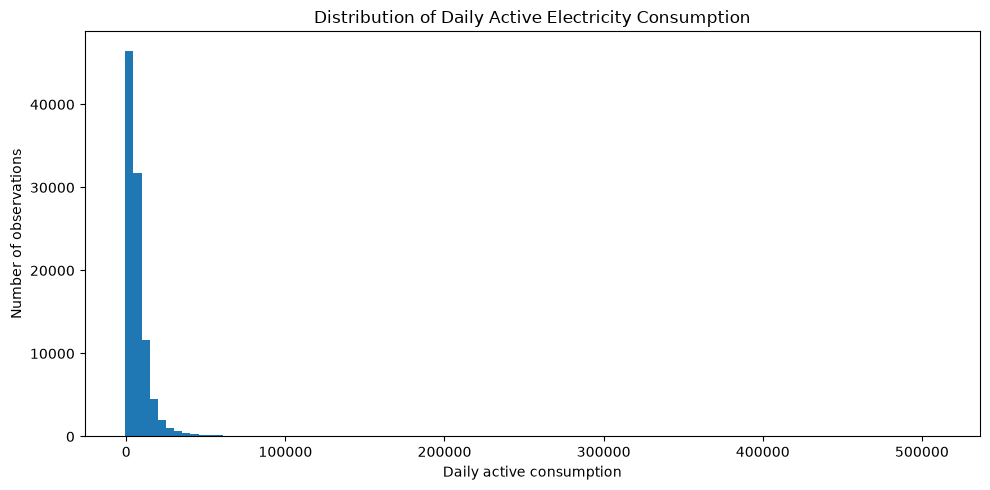

In [48]:
consumption_sample = (
    A
    .select("DAILY_ACTIVE_CONSUMPTION")
    .filter(
        pl.col("DAILY_ACTIVE_CONSUMPTION").is_not_null()
    )
    .collect()
    .sample(
        n=100_000,
        seed=42
    )
)

values = consumption_sample["DAILY_ACTIVE_CONSUMPTION"].to_numpy()

plt.figure(figsize=(10, 5))
plt.hist(values, bins=100)

plt.xlabel("Daily active consumption")
plt.ylabel("Number of observations")
plt.title("Distribution of Daily Active Electricity Consumption")

plt.tight_layout()
plt.show()

The distribution is expected to be right-skewed in electricity-consumption data, with many relatively small observations and a smaller number of high-consumption observations. The exact shape and extreme values will guide later feature transformations.

## Inspecting extreme observations

Rather than removing outliers immediately, I want to see the largest observations and where they occur.

In [49]:
largest_observations = (
    A
    .select([
        "CUSTOMER_ID",
        "DATE",
        "MUNICIPALITY",
        "CUSTOMER_TYPE",
        "MARKET",
        "DAILY_ACTIVE_CONSUMPTION",
    ])
    .sort("DAILY_ACTIVE_CONSUMPTION", descending=True)
    .head(20)
    .collect()
)

largest_observations

CUSTOMER_ID,DATE,MUNICIPALITY,CUSTOMER_TYPE,MARKET,DAILY_ACTIVE_CONSUMPTION
i64,date,str,str,str,i32
67072,2015-07-23,"""CASTELLON DE LA PLANA""","""T1""","""M2""",8215549
11933,2015-01-11,"""MADRID""","""T2""","""M2""",2481732
10745,2015-02-24,"""MADRID""","""T2""","""M2""",1473964
10618,2015-02-28,"""MADRID""","""T2""","""M2""",1213811
10618,2015-03-01,"""MADRID""","""T2""","""M2""",1112687
…,…,…,…,…,…
14181,2015-08-24,"""ESPARTINAS""","""T2""","""M2""",843205
14181,2015-08-17,"""ESPARTINAS""","""T2""","""M2""",822845
14181,2015-09-27,"""ESPARTINAS""","""T2""","""M2""",817946


This inspection helps determine whether extreme values are isolated observations, concentrated in particular customer categories, or associated with particular municipalities. Extreme values will not be deleted merely because they are large.

## Exploring electricity consumption over time

Now we can move from individual observations to the overall temporal pattern.

The daily aggregation shows how much active electricity consumption is represented in Table A on each date.

In [50]:
daily_consumption = (
    A
    .group_by("DATE")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("total_consumption"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("mean_consumption"),
        pl.col("CUSTOMER_ID").n_unique().alias("customers"),
        pl.len().alias("observations"),
    ])
    .sort("DATE")
    .collect()
)

daily_consumption.head()

DATE,total_consumption,mean_consumption,customers,observations
date,i32,f64,u32,u32
2013-09-13,2441,2441.0,1,1
2013-09-14,2633,2633.0,1,1
2013-09-15,2672,2672.0,1,1
2013-09-16,2571,2571.0,1,1
2013-09-17,2472,2472.0,1,1


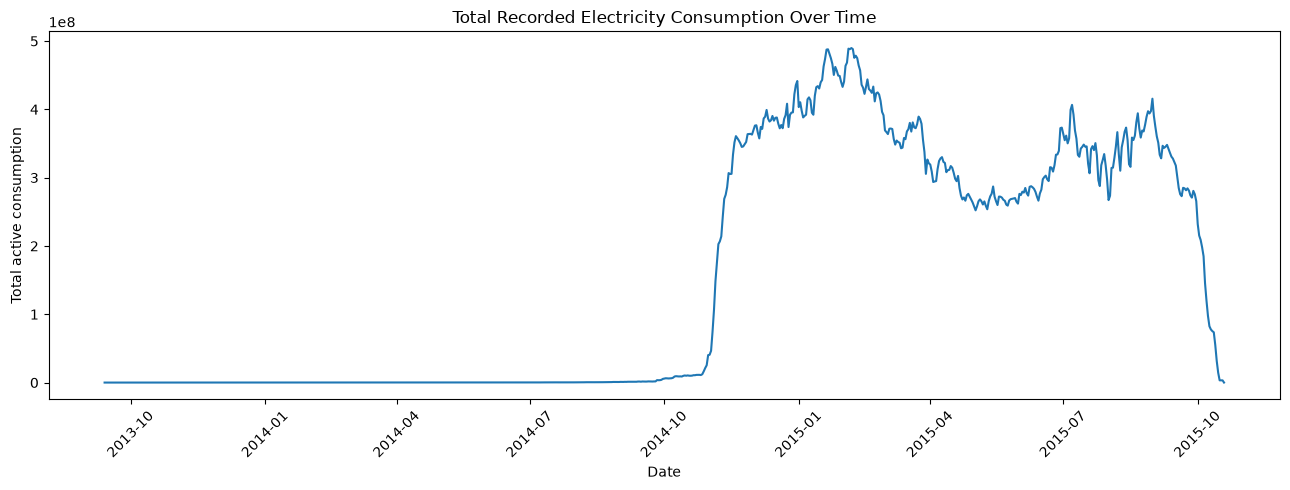

In [51]:
plt.figure(figsize=(13, 5))
plt.plot(
    daily_consumption["DATE"].to_numpy(),
    daily_consumption["total_consumption"].to_numpy()
)
plt.xlabel("Date")
plt.ylabel("Total active consumption")
plt.title("Total Recorded Electricity Consumption Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The total daily series should always be interpreted together with the number of customers and observations. A change in the total may reflect a real consumption pattern, a change in coverage, or both.

## Looking at the hourly consumption profile

The 25 active-energy columns can also be examined as a general load profile.

This gives a first idea of whether consumption is concentrated at particular positions in the day.

In [52]:
hourly_profile = []

for i, c in enumerate(active_cols, start=1):
    row = (
        A
        .select([
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    hourly_profile.append({
        "time_position": i,
        "mean_consumption": row[0],
        "median_consumption": row[1],
    })

hourly_profile = pl.DataFrame(hourly_profile)
hourly_profile

time_position,mean_consumption,median_consumption
i64,f64,f64
1,271.243332,137.0
2,219.068157,108.0
3,190.031017,96.0
4,175.119929,90.0
5,169.011401,88.0
…,…,…
21,407.396199,202.0
22,435.502118,233.0
23,407.421455,223.0


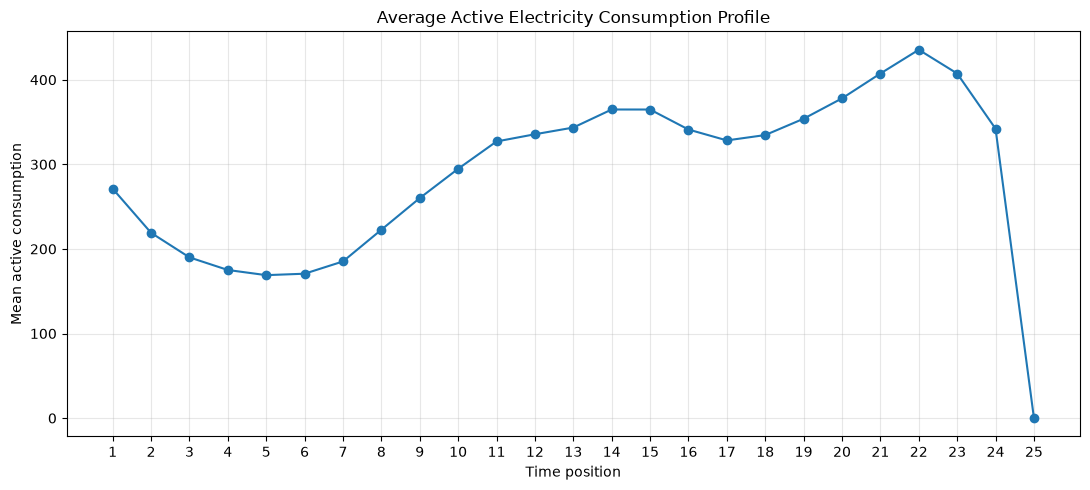

In [53]:
plt.figure(figsize=(11, 5))
plt.plot(
    hourly_profile["time_position"].to_numpy(),
    hourly_profile["mean_consumption"].to_numpy(),
    marker="o"
)
plt.xlabel("Time position")
plt.ylabel("Mean active consumption")
plt.title("Average Active Electricity Consumption Profile")
plt.xticks(range(1, 26))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The shape of this profile will later be useful when comparing municipalities. Municipalities can have similar total consumption while having different daily load shapes.

## Exploring the municipalities

We can now answer the first major project question.

First, I will aggregate the observed active consumption by municipality.

In [54]:
municipality_totals = (
    A
    .group_by("MUNICIPALITY")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("TOTAL_CONSUMPTION"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("MEAN_OBSERVATION_CONSUMPTION"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").median().alias("MEDIAN_OBSERVATION_CONSUMPTION"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.len().alias("OBSERVATIONS"),
        pl.col("DATE").n_unique().alias("OBSERVED_DAYS"),
    ])
    .with_columns([
        (
            pl.col("TOTAL_CONSUMPTION") /
            pl.col("CUSTOMERS")
        ).alias("CONSUMPTION_PER_CUSTOMER"),
        (
            pl.col("OBSERVATIONS") /
            pl.col("CUSTOMERS")
        ).alias("OBSERVATIONS_PER_CUSTOMER"),
    ])
    .sort("TOTAL_CONSUMPTION", descending=True)
    .collect()
)

municipality_totals.head(20)

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,MEDIAN_OBSERVATION_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER
str,i32,f64,f64,u32,u32,u32,f64,f64
"""SALAMANCA""",1877542555,7144.894627,4846.0,1530,262781,399,1.2272e6,171.752288
"""ZARAGOZA""",1795923841,6293.14047,4895.0,1731,285378,355,1.0375e6,164.863085
"""BILBAO""",1661028316,7804.483936,5408.0,1268,212830,408,1.3100e6,167.847003
"""UBRIQUE""",1648467828,6060.699459,4661.0,1666,271993,355,989476.487395,163.261104
"""ALBACETE""",1602193404,9454.364911,6054.0,958,169466,376,1.6724e6,176.895616
…,…,…,…,…,…,…,…,…
"""CAZORLA""",1088314445,4276.049431,1656.0,1611,254514,361,675552.107387,157.985102
"""MALAGA""",960539038,6651.37965,5056.0,931,144412,348,1.0317e6,155.11493
"""GRANADA""",888383224,6376.9783,4452.0,870,139311,358,1.0211e6,160.127586


### Highest-consuming municipalities

The ranking below is based on **total recorded active electricity consumption** in Table A.

This is the direct answer to the first project question, subject to the coverage and cleaning decisions documented above.

In [55]:
top_20 = municipality_totals.head(20)

top_20

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,MEDIAN_OBSERVATION_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER
str,i32,f64,f64,u32,u32,u32,f64,f64
"""SALAMANCA""",1877542555,7144.894627,4846.0,1530,262781,399,1.2272e6,171.752288
"""ZARAGOZA""",1795923841,6293.14047,4895.0,1731,285378,355,1.0375e6,164.863085
"""BILBAO""",1661028316,7804.483936,5408.0,1268,212830,408,1.3100e6,167.847003
"""UBRIQUE""",1648467828,6060.699459,4661.0,1666,271993,355,989476.487395,163.261104
"""ALBACETE""",1602193404,9454.364911,6054.0,958,169466,376,1.6724e6,176.895616
…,…,…,…,…,…,…,…,…
"""CAZORLA""",1088314445,4276.049431,1656.0,1611,254514,361,675552.107387,157.985102
"""MALAGA""",960539038,6651.37965,5056.0,931,144412,348,1.0317e6,155.11493
"""GRANADA""",888383224,6376.9783,4452.0,870,139311,358,1.0211e6,160.127586


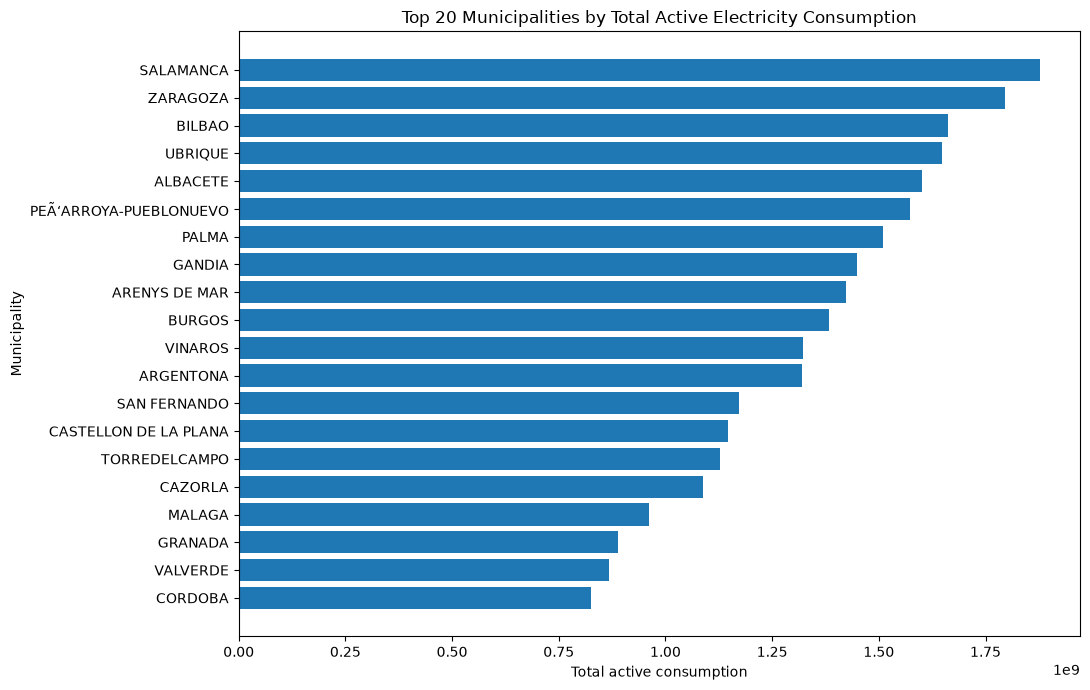

In [56]:
plt.figure(figsize=(11, 7))
plt.barh(
    top_20["MUNICIPALITY"].to_list()[::-1],
    top_20["TOTAL_CONSUMPTION"].to_list()[::-1]
)
plt.xlabel("Total active consumption")
plt.ylabel("Municipality")
plt.title("Top 20 Municipalities by Total Active Electricity Consumption")
plt.tight_layout()
plt.show()

## Total consumption versus consumption per customer

A municipality can rank highly simply because it has many customers.

To avoid confusing municipality size with customer-level consumption, I also examine consumption per customer.

In [57]:
top_per_customer = (
    municipality_totals
    .sort("CONSUMPTION_PER_CUSTOMER", descending=True)
    .head(20)
)

top_per_customer

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,MEDIAN_OBSERVATION_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER
str,i32,f64,f64,u32,u32,u32,f64,f64
"""ALHAURIN DE LA TORRE""",45460997,133708.814706,127898.5,1,340,335,4.5460997e7,340.0
"""RODA DE ANDALUCIA (LA)""",42752073,51138.843301,58145.5,3,836,329,1.4250691e7,278.666667
"""PEDRERA""",26454884,48809.749077,63937.5,2,542,312,1.3227442e7,271.0
"""LA SERNA""",13149374,39369.383234,38124.5,1,334,334,1.3149374e7,334.0
"""PILOÃ‘A""",11848342,51966.412281,54403.0,1,228,216,1.1848342e7,228.0
…,…,…,…,…,…,…,…,…
"""MONFERO""",7654192,27732.57971,27960.5,1,276,242,7.654192e6,276.0
"""ESPARTINAS""",60319807,33124.550796,10388.0,8,1821,345,7.5400e6,227.625
"""VALDEVIMBRE""",7310402,25208.282759,19783.0,1,290,238,7.310402e6,290.0


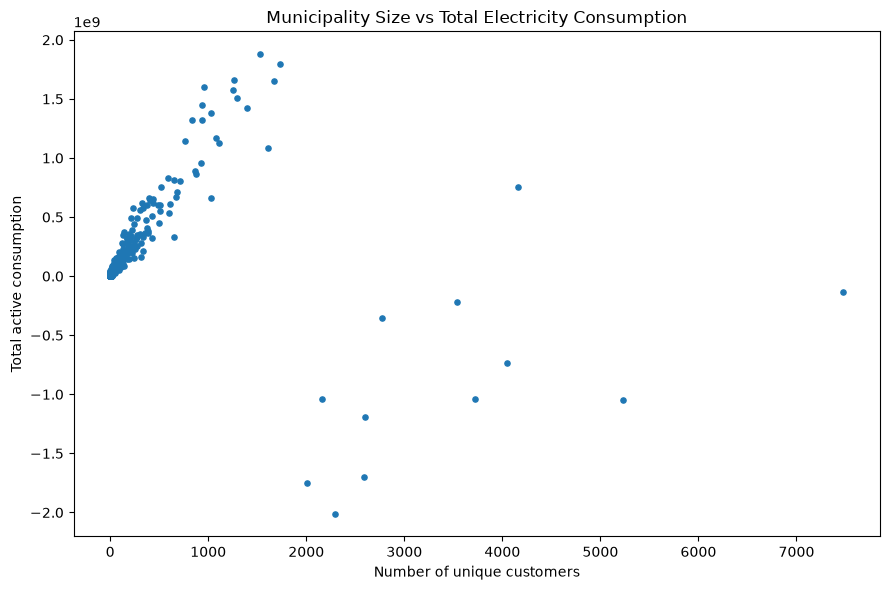

In [58]:
plt.figure(figsize=(9, 6))
plt.scatter(
    municipality_totals["CUSTOMERS"].to_numpy(),
    municipality_totals["TOTAL_CONSUMPTION"].to_numpy(),
    s=14
)
plt.xlabel("Number of unique customers")
plt.ylabel("Total active consumption")
plt.title("Municipality Size vs Total Electricity Consumption")
plt.tight_layout()
plt.show()

This distinction is important for the final report:

- **total consumption** identifies municipalities with the largest aggregate electricity use;
- **consumption per customer** provides a different view of consumption intensity.

Both measures can be useful for understanding the municipality landscape.

## Monthly municipality patterns

Total consumption tells us how large a municipality's electricity use is, but it does not tell us how stable that consumption is over time.

I will therefore build a municipality-by-month table.

In [59]:
A_monthly = A.with_columns(
    pl.col("DATE").dt.strftime("%Y-%m").alias("MONTH")
)

municipality_monthly = (
    A_monthly
    .group_by(["MUNICIPALITY", "MONTH"])
    .agg(
        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .sum()
        .alias("MONTHLY_CONSUMPTION")
    )
    .sort(["MUNICIPALITY", "MONTH"])
    .collect()
)

municipality_monthly.head()

MUNICIPALITY,MONTH,MONTHLY_CONSUMPTION
str,str,i32
"""A CORUÃ‘A""","""2013-09""",43222
"""A CORUÃ‘A""","""2013-10""",50905
"""A CORUÃ‘A""","""2013-11""",78069
"""A CORUÃ‘A""","""2013-12""",88333
"""A CORUÃ‘A""","""2014-01""",91083


## Heat map of municipality consumption over time

A heat map is useful here because it lets us compare many municipalities and months at the same time.

To keep the plot readable, the heat map focuses on the 20 municipalities with the highest total consumption.

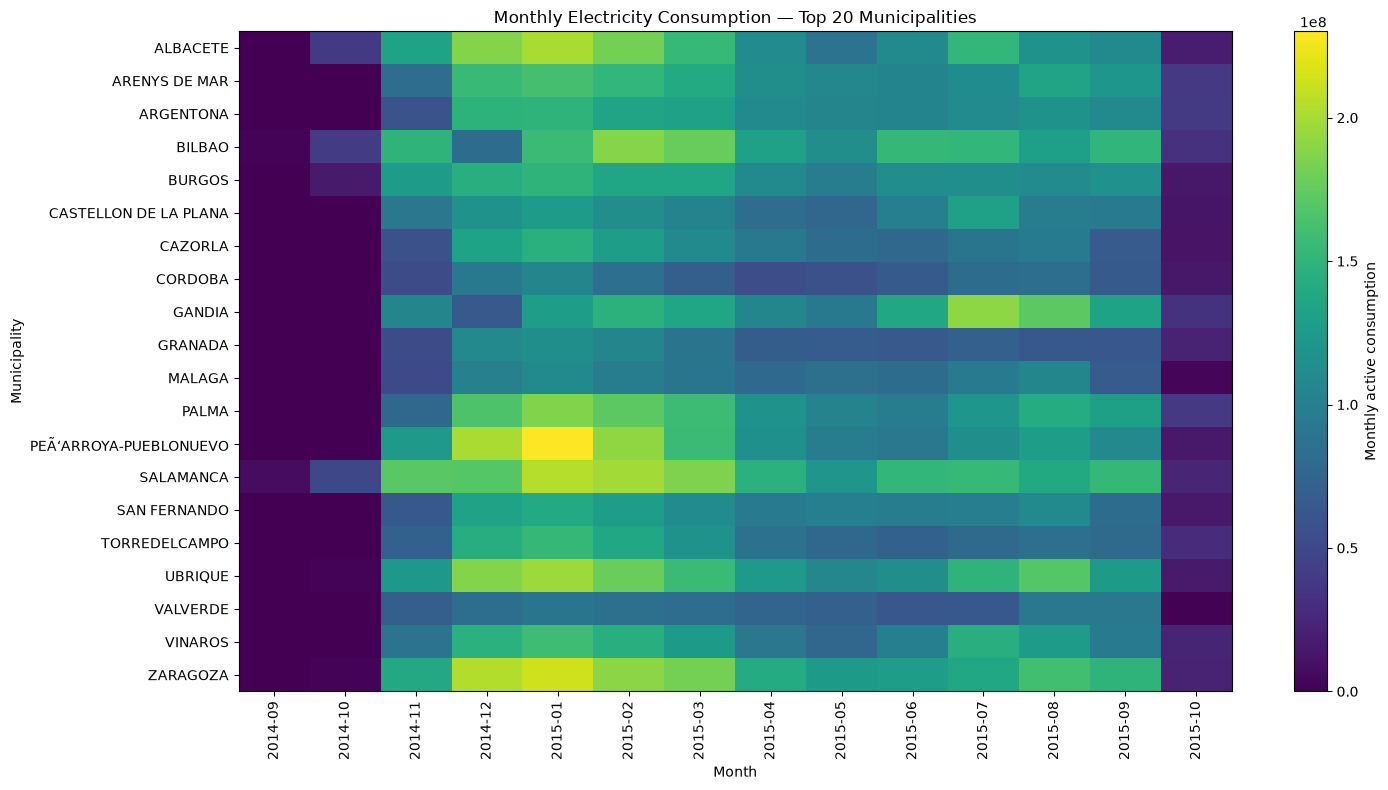

In [60]:
top_names = top_20["MUNICIPALITY"].to_list()

heatmap_data = (
    municipality_monthly
    .filter(pl.col("MUNICIPALITY").is_in(top_names))
    .pivot(
        on="MONTH",
        index="MUNICIPALITY",
        values="MONTHLY_CONSUMPTION",
        aggregate_function="sum",
    )
)

months = sorted([
    c for c in heatmap_data.columns
    if c != "MUNICIPALITY"
])

heatmap_matrix = heatmap_data.select(months).to_numpy()

plt.figure(figsize=(15, 8))
plt.imshow(
    heatmap_matrix,
    aspect="auto",
    interpolation="nearest"
)
plt.xticks(
    range(len(months)),
    months,
    rotation=90
)
plt.yticks(
    range(heatmap_data.height),
    heatmap_data["MUNICIPALITY"].to_list()
)
plt.xlabel("Month")
plt.ylabel("Municipality")
plt.title("Monthly Electricity Consumption — Top 20 Municipalities")
plt.colorbar(label="Monthly active consumption")
plt.tight_layout()
plt.show()

The heat map makes seasonal and temporal differences easier to see than a single municipality ranking. These differences will later contribute to the municipality clustering features.

## Customer characteristics and municipality composition

Municipalities can have different consumption patterns because their customer populations are different.

I will therefore inspect the customer-type and market composition of the observations.

In [61]:
customer_type_distribution = (
    A
    .group_by("CUSTOMER_TYPE")
    .agg([
        pl.len().alias("OBSERVATIONS"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.col("MUNICIPALITY").n_unique().alias("MUNICIPALITIES"),
    ])
    .sort("OBSERVATIONS", descending=True)
    .collect()
)

customer_type_distribution

CUSTOMER_TYPE,OBSERVATIONS,CUSTOMERS,MUNICIPALITIES
str,u32,u32,u32
"""T1""",13397442,83002,741
"""T2""",2758282,16997,528


In [62]:
market_distribution = (
    A
    .group_by("MARKET")
    .agg([
        pl.len().alias("OBSERVATIONS"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.col("MUNICIPALITY").n_unique().alias("MUNICIPALITIES"),
    ])
    .sort("OBSERVATIONS", descending=True)
    .collect()
)

market_distribution

MARKET,OBSERVATIONS,CUSTOMERS,MUNICIPALITIES
str,u32,u32,u32
"""M1""",9295674,58291,454
"""M2""",6860050,41710,668


In [63]:
product_distribution = (
    A
    .group_by("ELECTRICITY_PRODUCT")
    .agg([
        pl.len().alias("OBSERVATIONS"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
    ])
    .sort("OBSERVATIONS", descending=True)
    .collect()
)

product_distribution.head(30)

ELECTRICITY_PRODUCT,OBSERVATIONS,CUSTOMERS
str,u32,u32
"""P1""",8866013,55637
"""P13""",2867221,17332
"""P30""",1284565,7907
"""P17""",574132,3566
"""P2""",341649,2114
…,…,…
"""P52""",18098,105
"""P26""",17499,115
"""P32""",15612,106


## Building a data cube

A data cube gives us a multidimensional view of the same consumption measure.

For this project, the cube uses:

- **Month**
- **Municipality**
- **Customer type**
- **Market**

and stores several measures, including total consumption, mean consumption, number of customers, and number of observations.

This is useful because it lets us ask questions such as:

- How much consumption came from domestic versus non-domestic customers?
- How does this change by municipality?
- Does market composition differ between high-consuming municipalities?

In [64]:
data_cube = (
    A_monthly
    .group_by([
        "MONTH",
        "MUNICIPALITY",
        "CUSTOMER_TYPE",
        "MARKET",
    ])
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .sum()
        .alias("TOTAL_ACTIVE_CONSUMPTION"),

        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .mean()
        .alias("MEAN_OBSERVATION_CONSUMPTION"),

        pl.col("CUSTOMER_ID")
        .n_unique()
        .alias("UNIQUE_CUSTOMERS"),

        pl.len()
        .alias("OBSERVATIONS"),
    ])
    .sort([
        "MONTH",
        "MUNICIPALITY",
        "CUSTOMER_TYPE",
        "MARKET",
    ])
    .collect()
)

print(f"Data cube rows: {data_cube.height:,}")
data_cube.head(20)

Data cube rows: 20,100


MONTH,MUNICIPALITY,CUSTOMER_TYPE,MARKET,TOTAL_ACTIVE_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,UNIQUE_CUSTOMERS,OBSERVATIONS
str,str,str,str,i32,f64,u32,u32
"""2013-09""","""A CORUÃ‘A""","""T2""","""M2""",43222,2542.470588,1,17
"""2013-10""","""A CORUÃ‘A""","""T2""","""M2""",50905,2424.047619,1,21
"""2013-11""","""A CORUÃ‘A""","""T2""","""M2""",78069,2891.444444,1,27
"""2013-12""","""A CORUÃ‘A""","""T2""","""M2""",88333,3271.592593,1,27
"""2014-01""","""A CORUÃ‘A""","""T2""","""M2""",91083,3252.964286,1,28
…,…,…,…,…,…,…,…
"""2014-06""","""CIUDAD REAL""","""T1""","""M2""",3439,149.521739,1,23
"""2014-06""","""COSLADA""","""T2""","""M2""",10439,2087.8,1,5
"""2014-06""","""MADRID""","""T2""","""M2""",712043,26371.962963,1,27


### Exploring the cube

The cube is not a replacement for the raw data. It is a compact analytical view that makes multidimensional questions easier to answer.

In [65]:
data_cube.sort(
    "TOTAL_ACTIVE_CONSUMPTION",
    descending=True
).head(20)

MONTH,MUNICIPALITY,CUSTOMER_TYPE,MARKET,TOTAL_ACTIVE_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,UNIQUE_CUSTOMERS,OBSERVATIONS
str,str,str,str,i32,f64,u32,u32
"""2015-07""","""MADRID""","""T1""","""M2""",782848837,7364.731244,6580,106297
"""2015-02""","""MADRID""","""T1""","""M2""",668410028,6812.863398,6581,98110
"""2015-03""","""MADRID""","""T1""","""M2""",627175601,5834.354456,6610,107497
"""2015-06""","""MADRID""","""T1""","""M2""",585213700,5684.666718,6583,102946
"""2014-11""","""MADRID""","""T1""","""M2""",563442195,6145.010906,6580,91691
…,…,…,…,…,…,…,…
"""2015-02""","""MAIRENA DEL ALCOR""","""T1""","""M1""",341957061,10689.498625,2323,31990
"""2014-12""","""SANT BOI DE LLOBREGAT""","""T1""","""M1""",335362068,8774.058605,2358,38222
"""2015-02""","""RUBI""","""T1""","""M1""",332291611,9187.447772,2460,36168


In [66]:
municipality_customer_type = (
    data_cube
    .group_by(["MUNICIPALITY", "CUSTOMER_TYPE"])
    .agg(
        pl.col("TOTAL_ACTIVE_CONSUMPTION")
        .sum()
        .alias("TOTAL_CONSUMPTION")
    )
    .sort("TOTAL_CONSUMPTION", descending=True)
)

municipality_customer_type.head(20)

MUNICIPALITY,CUSTOMER_TYPE,TOTAL_CONSUMPTION
str,str,i32
"""SANT CARLES DE LA RAPITA""","""T1""",2127291950
"""HUELVA""","""T1""",1952421795
"""MADRID""","""T1""",1871098286
"""SANTANDER""","""T1""",1658409029
"""ZARAGOZA""","""T1""",1468487659
…,…,…
"""BILBAO""","""T1""",1014995038
"""CAZORLA""","""T1""",980236790
"""TORREDELCAMPO""","""T1""",972210626


## Creating municipality-level features for clustering

The clustering problem is different from the raw-data problem.

We do not want to cluster 16 million individual records. The object we want to cluster is the **municipality**.

Therefore, the next step is to turn the observations into one feature vector per municipality.

The features will describe:

- total consumption,
- consumption per customer,
- variability,
- number of customers and observed days,
- customer composition,
- market composition,
- and hourly consumption shape.

In [67]:
# Core municipality features

municipality_features = (
    A
    .group_by("MUNICIPALITY")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .sum()
        .alias("TOTAL_CONSUMPTION"),

        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .mean()
        .alias("MEAN_CONSUMPTION"),

        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .median()
        .alias("MEDIAN_CONSUMPTION"),

        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .std()
        .alias("STD_CONSUMPTION"),

        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .quantile(0.90)
        .alias("P90_CONSUMPTION"),

        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .quantile(0.99)
        .alias("P99_CONSUMPTION"),

        pl.col("CUSTOMER_ID")
        .n_unique()
        .alias("CUSTOMERS"),

        pl.len()
        .alias("OBSERVATIONS"),

        pl.col("DATE")
        .n_unique()
        .alias("OBSERVED_DAYS"),

        *[
            pl.col(c).mean().alias(f"MEAN_{c}")
            for c in active_cols
        ],
    ])
    .with_columns([
        (
            pl.col("TOTAL_CONSUMPTION") /
            pl.col("CUSTOMERS")
        ).alias("CONSUMPTION_PER_CUSTOMER"),

        (
            pl.col("OBSERVATIONS") /
            pl.col("CUSTOMERS")
        ).alias("OBSERVATIONS_PER_CUSTOMER"),
    ])
    .collect()
)

municipality_features.head()

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,MEDIAN_CONSUMPTION,STD_CONSUMPTION,P90_CONSUMPTION,P99_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,MEAN_ACTIVE_H25,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER
str,i32,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALCOBENDAS""",1496320,4548.085106,3414.0,2827.936445,8521.0,13841.0,3,329,237,174.06079,133.613982,114.553191,105.401216,103.173252,97.519757,116.398176,133.56231,119.56231,150.43769,194.759878,200.942249,231.115502,255.723404,228.924012,227.021277,240.711246,216.364742,227.057751,222.048632,254.81155,287.942249,291.0,221.379939,0.0,498773.333333,109.666667
"""POIO""",16304188,40457.042184,45584.0,28356.654115,80732.0,101295.0,2,403,320,1699.171216,1202.07196,986.347395,907.253102,897.965261,842.28536,862.545906,1283.841191,1537.362283,2362.930521,2089.434243,2044.203474,1946.942928,1999.034739,2023.215881,1978.312655,1745.811414,1613.305211,1760.369727,1910.563275,2061.880893,2329.960298,2318.545906,2053.687345,0.0,8.152094e6,201.5
"""SANTA LUCIA DE TIRAJANA""",51207048,6235.636629,5743.5,3789.065964,10931.0,16493.0,47,8212,352,206.968461,154.926571,130.810887,117.568802,112.725402,122.779713,149.954213,200.543473,239.055041,226.129566,265.72114,280.078422,328.280321,349.617511,317.476011,282.795908,282.121895,288.498295,312.325377,373.240136,417.341939,424.831466,367.949586,283.896493,0.0,1.0895e6,174.723404
"""MONTMANEU""",2937248,5970.01626,4410.5,10857.768106,13181.0,62336.0,3,492,299,179.912602,167.083333,165.737805,163.060976,175.331301,176.408537,202.843496,241.752033,367.018293,375.660569,347.804878,357.443089,475.00813,415.941057,253.939024,231.827236,210.760163,195.664634,193.871951,214.166667,231.195122,240.046748,205.28252,182.256098,0.0,979082.666667,164.0
"""BUSTILLO DE LA VEGA""",19612905,24608.412798,14983.0,20520.722337,51766.0,54662.0,4,797,334,632.230866,598.090339,469.323714,395.848181,356.209536,343.757842,620.72271,1701.504391,2620.941029,2289.683814,1316.013802,859.934755,664.347553,647.415307,668.441656,583.622334,452.099122,437.032622,1450.308657,2792.987453,2154.535759,1014.801757,856.271016,682.288582,0.0,4.9032e6,199.25


### Creating an hourly load-shape representation

Raw hourly consumption levels are strongly affected by municipality size.

For clustering, the shape is often more informative than the absolute magnitude. I therefore normalize each municipality's average hourly profile by its own total average profile.

In [68]:
mean_hour_cols = [f"MEAN_ACTIVE_H{i}" for i in range(1, 26)]

municipality_features = municipality_features.with_columns(
    pl.sum_horizontal([
        pl.col(c).fill_null(0)
        for c in mean_hour_cols
    ]).alias("_MEAN_PROFILE_TOTAL")
)

municipality_features = municipality_features.with_columns([
    (
        pl.col(c).fill_null(0) /
        pl.col("_MEAN_PROFILE_TOTAL").replace(0, None)
    ).alias(f"SHAPE_H{i}")
    for i, c in enumerate(mean_hour_cols, start=1)
])

municipality_features = municipality_features.drop("_MEAN_PROFILE_TOTAL")

municipality_features.head()

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,MEDIAN_CONSUMPTION,STD_CONSUMPTION,P90_CONSUMPTION,P99_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,MEAN_ACTIVE_H25,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24,SHAPE_H25
str,i32,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALCOBENDAS""",1496320,4548.085106,3414.0,2827.936445,8521.0,13841.0,3,329,237,174.06079,133.613982,114.553191,105.401216,103.173252,97.519757,116.398176,133.56231,119.56231,150.43769,194.759878,200.942249,231.115502,255.723404,228.924012,227.021277,240.711246,216.364742,227.057751,222.048632,254.81155,287.942249,291.0,221.379939,0.0,498773.333333,109.666667,0.038271,0.029378,0.025187,0.023175,0.022685,0.021442,0.025593,0.029367,0.026288,0.033077,0.042822,0.044182,0.050816,0.056227,0.050334,0.049916,0.052926,0.047573,0.049924,0.048822,0.056026,0.063311,0.063983,0.048675,0.0
"""POIO""",16304188,40457.042184,45584.0,28356.654115,80732.0,101295.0,2,403,320,1699.171216,1202.07196,986.347395,907.253102,897.965261,842.28536,862.545906,1283.841191,1537.362283,2362.930521,2089.434243,2044.203474,1946.942928,1999.034739,2023.215881,1978.312655,1745.811414,1613.305211,1760.369727,1910.563275,2061.880893,2329.960298,2318.545906,2053.687345,0.0,8.152094e6,201.5,0.041999,0.029712,0.02438,0.022425,0.022196,0.020819,0.02132,0.031733,0.038,0.058406,0.051646,0.050528,0.048124,0.049411,0.050009,0.048899,0.043152,0.039877,0.043512,0.047224,0.050965,0.057591,0.057309,0.050762,0.0
"""SANTA LUCIA DE TIRAJANA""",51207048,6235.636629,5743.5,3789.065964,10931.0,16493.0,47,8212,352,206.968461,154.926571,130.810887,117.568802,112.725402,122.779713,149.954213,200.543473,239.055041,226.129566,265.72114,280.078422,328.280321,349.617511,317.476011,282.795908,282.121895,288.498295,312.325377,373.240136,417.341939,424.831466,367.949586,283.896493,0.0,1.0895e6,174.723404,0.033191,0.024845,0.020978,0.018854,0.018078,0.01969,0.024048,0.032161,0.038337,0.036264,0.042613,0.044916,0.052646,0.056068,0.050913,0.045352,0.045243,0.046266,0.050087,0.059856,0.066929,0.06813,0.059008,0.045528,0.0
"""MONTMANEU""",2937248,5970.01626,4410.5,10857.768106,13181.0,62336.0,3,492,299,179.912602,167.083333,165.737805,163.060976,175.331301,176.408537,202.843496,241.752033,367.018293,375.660569,347.804878,357.443089,475.00813,415.941057,253.939024,231.827236,210.760163,195.664634,193.871951,214.166667,231.195122,240.046748,205.28252,182.256098,0.0,979082.666667,164.0,0.030136,0.027987,0.027762,0.027313,0.029369,0.029549,0.033977,0.040494,0.061477,0.062925,0.058259,0.059873,0.079566,0.069672,0.042536,0.038832,0.035303,0.032775,0.032474,0.035874,0.038726,0.040209,0.034386,0.030529,0.0
"""BUSTILLO DE LA VEGA""",19612905,24608.412798,14983.0,20520.722337,51766.0,54662.0,4,797,334,632.230866,598.090339,469.323714,395.848181,356.209536,343.757842,620.72271,1701.504391,2620.941029,2289.683814,1316.013802,859.934755,664.347553,647.415307,668.441656,583.622334,452.099122,437.032622,1450.308657,2792.987453,2154.535759,1014.801757,856.271016,682.288582,0.0,4.9032e6,199.25,0.025692,0.024304,0.019072,0.016086,0.014475,0.013969,0.025224,0.069143,0.106506,0.093045,0.053478,0.034945,0.026997,0.026309,0.027163,0.023716,0.018372,0.01775

The `SHAPE_H1`–`SHAPE_H25` variables describe the relative distribution of a municipality's average consumption across the day. They help distinguish municipalities with similar total consumption but different load profiles.

## Customer-type composition by municipality

In [69]:
customer_type_counts = (
    A
    .select(["MUNICIPALITY", "CUSTOMER_TYPE"])
    .group_by(["MUNICIPALITY", "CUSTOMER_TYPE"])
    .agg(pl.len().alias("N"))
    .collect()
)

customer_type_totals = (
    customer_type_counts
    .group_by("MUNICIPALITY")
    .agg(pl.col("N").sum().alias("TOTAL_N"))
)

customer_type_shares = (
    customer_type_counts
    .join(customer_type_totals, on="MUNICIPALITY")
    .with_columns(
        (pl.col("N") / pl.col("TOTAL_N")).alias("SHARE")
    )
)

customer_type_wide = (
    customer_type_shares
    .pivot(
        on="CUSTOMER_TYPE",
        index="MUNICIPALITY",
        values="SHARE",
        aggregate_function="sum",
    )
)

customer_type_wide

MUNICIPALITY,T1,T2
str,f64,f64
"""GUARDAMAR DEL SEGURA""",1.0,0.0
"""MONDA""",0.757675,0.242325
"""CARTAGENA""",0.940495,0.059505
"""CORIA DEL RIO""",0.0,1.0
"""OSORNO LA MAYOR""",0.767009,0.232991
…,…,…
"""VILLAR DEL OLMO""",1.0,0.0
"""LA VECILLA""",1.0,0.0
"""BENASAU""",0.0,1.0


In [70]:
# Give composition features explicit names.
customer_type_columns = [
    c for c in customer_type_wide.columns
    if c != "MUNICIPALITY"
]

customer_type_wide = customer_type_wide.rename({
    c: f"CUSTOMER_TYPE_SHARE_{c}"
    for c in customer_type_columns
})

municipality_features = municipality_features.join(
    customer_type_wide,
    on="MUNICIPALITY",
    how="left"
)

municipality_features.head()

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,MEDIAN_CONSUMPTION,STD_CONSUMPTION,P90_CONSUMPTION,P99_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,MEAN_ACTIVE_H25,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24,SHAPE_H25,CUSTOMER_TYPE_SHARE_T1,CUSTOMER_TYPE_SHARE_T2
str,i32,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALCOBENDAS""",1496320,4548.085106,3414.0,2827.936445,8521.0,13841.0,3,329,237,174.06079,133.613982,114.553191,105.401216,103.173252,97.519757,116.398176,133.56231,119.56231,150.43769,194.759878,200.942249,231.115502,255.723404,228.924012,227.021277,240.711246,216.364742,227.057751,222.048632,254.81155,287.942249,291.0,221.379939,0.0,498773.333333,109.666667,0.038271,0.029378,0.025187,0.023175,0.022685,0.021442,0.025593,0.029367,0.026288,0.033077,0.042822,0.044182,0.050816,0.056227,0.050334,0.049916,0.052926,0.047573,0.049924,0.048822,0.056026,0.063311,0.063983,0.048675,0.0,1.0,0.0
"""POIO""",16304188,40457.042184,45584.0,28356.654115,80732.0,101295.0,2,403,320,1699.171216,1202.07196,986.347395,907.253102,897.965261,842.28536,862.545906,1283.841191,1537.362283,2362.930521,2089.434243,2044.203474,1946.942928,1999.034739,2023.215881,1978.312655,1745.811414,1613.305211,1760.369727,1910.563275,2061.880893,2329.960298,2318.545906,2053.687345,0.0,8.152094e6,201.5,0.041999,0.029712,0.02438,0.022425,0.022196,0.020819,0.02132,0.031733,0.038,0.058406,0.051646,0.050528,0.048124,0.049411,0.050009,0.048899,0.043152,0.039877,0.043512,0.047224,0.050965,0.057591,0.057309,0.050762,0.0,0.33995,0.66005
"""SANTA LUCIA DE TIRAJANA""",51207048,6235.636629,5743.5,3789.065964,10931.0,16493.0,47,8212,352,206.968461,154.926571,130.810887,117.568802,112.725402,122.779713,149.954213,200.543473,239.055041,226.129566,265.72114,280.078422,328.280321,349.617511,317.476011,282.795908,282.121895,288.498295,312.325377,373.240136,417.341939,424.831466,367.949586,283.896493,0.0,1.0895e6,174.723404,0.033191,0.024845,0.020978,0.018854,0.018078,0.01969,0.024048,0.032161,0.038337,0.036264,0.042613,0.044916,0.052646,0.056068,0.050913,0.045352,0.045243,0.046266,0.050087,0.059856,0.066929,0.06813,0.059008,0.045528,0.0,0.811374,0.188626
"""MONTMANEU""",2937248,5970.01626,4410.5,10857.768106,13181.0,62336.0,3,492,299,179.912602,167.083333,165.737805,163.060976,175.331301,176.408537,202.843496,241.752033,367.018293,375.660569,347.804878,357.443089,475.00813,415.941057,253.939024,231.827236,210.760163,195.664634,193.871951,214.166667,231.195122,240.046748,205.28252,182.256098,0.0,979082.666667,164.0,0.030136,0.027987,0.027762,0.027313,0.029369,0.029549,0.033977,0.040494,0.061477,0.062925,0.058259,0.059873,0.079566,0.069672,0.042536,0.038832,0.035303,0.032775,0.032474,0.035874,0.038726,0.040209,0.034386,0.030529,0.0,0.53252,0.46748
"""BUSTILLO DE LA VEGA""",19612905,24608.412798,14983.0,20520.722337,51766.0,54662.0,4,797,334,632.230866,598.090339,469.323714,395.848181,356.209536,343.757842,620.72271,1701.504391,2620.941029,2289.683814,1316.013802,859.934755,664.347553,647.415307,668.441656,583.622334,452.099122,437.032622,1450.308657,2792.987453,2154.535759,1014.801757,856.271016,682.288582,0.0,4.9032e6,199.25,0.025692,0.024304,0.019072,0.016086,0.014475,0.0

## Market composition by municipality

In [71]:
market_counts = (
    A
    .select(["MUNICIPALITY", "MARKET"])
    .group_by(["MUNICIPALITY", "MARKET"])
    .agg(pl.len().alias("N"))
    .collect()
)

market_totals = (
    market_counts
    .group_by("MUNICIPALITY")
    .agg(pl.col("N").sum().alias("TOTAL_N"))
)

market_shares = (
    market_counts
    .join(market_totals, on="MUNICIPALITY")
    .with_columns(
        (pl.col("N") / pl.col("TOTAL_N")).alias("SHARE")
    )
)

market_wide = (
    market_shares
    .pivot(
        on="MARKET",
        index="MUNICIPALITY",
        values="SHARE",
        aggregate_function="sum",
    )
)

market_columns = [
    c for c in market_wide.columns
    if c != "MUNICIPALITY"
]

market_wide = market_wide.rename({
    c: f"MARKET_SHARE_{c}"
    for c in market_columns
})

municipality_features = municipality_features.join(
    market_wide,
    on="MUNICIPALITY",
    how="left"
)

municipality_features.head()

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,MEDIAN_CONSUMPTION,STD_CONSUMPTION,P90_CONSUMPTION,P99_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,MEAN_ACTIVE_H25,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24,SHAPE_H25,CUSTOMER_TYPE_SHARE_T1,CUSTOMER_TYPE_SHARE_T2,MARKET_SHARE_M2,MARKET_SHARE_M1
str,i32,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALCOBENDAS""",1496320,4548.085106,3414.0,2827.936445,8521.0,13841.0,3,329,237,174.06079,133.613982,114.553191,105.401216,103.173252,97.519757,116.398176,133.56231,119.56231,150.43769,194.759878,200.942249,231.115502,255.723404,228.924012,227.021277,240.711246,216.364742,227.057751,222.048632,254.81155,287.942249,291.0,221.379939,0.0,498773.333333,109.666667,0.038271,0.029378,0.025187,0.023175,0.022685,0.021442,0.025593,0.029367,0.026288,0.033077,0.042822,0.044182,0.050816,0.056227,0.050334,0.049916,0.052926,0.047573,0.049924,0.048822,0.056026,0.063311,0.063983,0.048675,0.0,1.0,0.0,0.316109,0.683891
"""POIO""",16304188,40457.042184,45584.0,28356.654115,80732.0,101295.0,2,403,320,1699.171216,1202.07196,986.347395,907.253102,897.965261,842.28536,862.545906,1283.841191,1537.362283,2362.930521,2089.434243,2044.203474,1946.942928,1999.034739,2023.215881,1978.312655,1745.811414,1613.305211,1760.369727,1910.563275,2061.880893,2329.960298,2318.545906,2053.687345,0.0,8.152094e6,201.5,0.041999,0.029712,0.02438,0.022425,0.022196,0.020819,0.02132,0.031733,0.038,0.058406,0.051646,0.050528,0.048124,0.049411,0.050009,0.048899,0.043152,0.039877,0.043512,0.047224,0.050965,0.057591,0.057309,0.050762,0.0,0.33995,0.66005,1.0,0.0
"""SANTA LUCIA DE TIRAJANA""",51207048,6235.636629,5743.5,3789.065964,10931.0,16493.0,47,8212,352,206.968461,154.926571,130.810887,117.568802,112.725402,122.779713,149.954213,200.543473,239.055041,226.129566,265.72114,280.078422,328.280321,349.617511,317.476011,282.795908,282.121895,288.498295,312.325377,373.240136,417.341939,424.831466,367.949586,283.896493,0.0,1.0895e6,174.723404,0.033191,0.024845,0.020978,0.018854,0.018078,0.01969,0.024048,0.032161,0.038337,0.036264,0.042613,0.044916,0.052646,0.056068,0.050913,0.045352,0.045243,0.046266,0.050087,0.059856,0.066929,0.06813,0.059008,0.045528,0.0,0.811374,0.188626,0.521067,0.478933
"""MONTMANEU""",2937248,5970.01626,4410.5,10857.768106,13181.0,62336.0,3,492,299,179.912602,167.083333,165.737805,163.060976,175.331301,176.408537,202.843496,241.752033,367.018293,375.660569,347.804878,357.443089,475.00813,415.941057,253.939024,231.827236,210.760163,195.664634,193.871951,214.166667,231.195122,240.046748,205.28252,182.256098,0.0,979082.666667,164.0,0.030136,0.027987,0.027762,0.027313,0.029369,0.029549,0.033977,0.040494,0.061477,0.062925,0.058259,0.059873,0.079566,0.069672,0.042536,0.038832,0.035303,0.032775,0.032474,0.035874,0.038726,0.040209,0.034386,0.030529,0.0,0.53252,0.46748,0.943089,0.056911
"""BUSTILLO DE LA VEGA""",19612905,24608.412798,14983.0,20520.722337,51766.0,54662.0,4,797,334,632.230866,598.090339,469.323714,395.848181,356.209536,343.757842,620.72271,1701.504391,2620.941029,2289.683814,1316.013802,859.934755,664.347553,647.415307,668.441656,583.622334,452.099122,437.032622,1450.308657,2792.987453,2154.535759,

## Checking the municipality feature table

Before clustering, I want to make sure the feature table has one row per municipality and that there are no unexpected missing or infinite values.

In [72]:
print("Municipality rows:", municipality_features.height)
print("Feature columns:", len(municipality_features.columns))

municipality_features.head()

Municipality rows: 808
Feature columns: 66


MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,MEDIAN_CONSUMPTION,STD_CONSUMPTION,P90_CONSUMPTION,P99_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,MEAN_ACTIVE_H25,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24,SHAPE_H25,CUSTOMER_TYPE_SHARE_T1,CUSTOMER_TYPE_SHARE_T2,MARKET_SHARE_M2,MARKET_SHARE_M1
str,i32,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALCOBENDAS""",1496320,4548.085106,3414.0,2827.936445,8521.0,13841.0,3,329,237,174.06079,133.613982,114.553191,105.401216,103.173252,97.519757,116.398176,133.56231,119.56231,150.43769,194.759878,200.942249,231.115502,255.723404,228.924012,227.021277,240.711246,216.364742,227.057751,222.048632,254.81155,287.942249,291.0,221.379939,0.0,498773.333333,109.666667,0.038271,0.029378,0.025187,0.023175,0.022685,0.021442,0.025593,0.029367,0.026288,0.033077,0.042822,0.044182,0.050816,0.056227,0.050334,0.049916,0.052926,0.047573,0.049924,0.048822,0.056026,0.063311,0.063983,0.048675,0.0,1.0,0.0,0.316109,0.683891
"""POIO""",16304188,40457.042184,45584.0,28356.654115,80732.0,101295.0,2,403,320,1699.171216,1202.07196,986.347395,907.253102,897.965261,842.28536,862.545906,1283.841191,1537.362283,2362.930521,2089.434243,2044.203474,1946.942928,1999.034739,2023.215881,1978.312655,1745.811414,1613.305211,1760.369727,1910.563275,2061.880893,2329.960298,2318.545906,2053.687345,0.0,8.152094e6,201.5,0.041999,0.029712,0.02438,0.022425,0.022196,0.020819,0.02132,0.031733,0.038,0.058406,0.051646,0.050528,0.048124,0.049411,0.050009,0.048899,0.043152,0.039877,0.043512,0.047224,0.050965,0.057591,0.057309,0.050762,0.0,0.33995,0.66005,1.0,0.0
"""SANTA LUCIA DE TIRAJANA""",51207048,6235.636629,5743.5,3789.065964,10931.0,16493.0,47,8212,352,206.968461,154.926571,130.810887,117.568802,112.725402,122.779713,149.954213,200.543473,239.055041,226.129566,265.72114,280.078422,328.280321,349.617511,317.476011,282.795908,282.121895,288.498295,312.325377,373.240136,417.341939,424.831466,367.949586,283.896493,0.0,1.0895e6,174.723404,0.033191,0.024845,0.020978,0.018854,0.018078,0.01969,0.024048,0.032161,0.038337,0.036264,0.042613,0.044916,0.052646,0.056068,0.050913,0.045352,0.045243,0.046266,0.050087,0.059856,0.066929,0.06813,0.059008,0.045528,0.0,0.811374,0.188626,0.521067,0.478933
"""MONTMANEU""",2937248,5970.01626,4410.5,10857.768106,13181.0,62336.0,3,492,299,179.912602,167.083333,165.737805,163.060976,175.331301,176.408537,202.843496,241.752033,367.018293,375.660569,347.804878,357.443089,475.00813,415.941057,253.939024,231.827236,210.760163,195.664634,193.871951,214.166667,231.195122,240.046748,205.28252,182.256098,0.0,979082.666667,164.0,0.030136,0.027987,0.027762,0.027313,0.029369,0.029549,0.033977,0.040494,0.061477,0.062925,0.058259,0.059873,0.079566,0.069672,0.042536,0.038832,0.035303,0.032775,0.032474,0.035874,0.038726,0.040209,0.034386,0.030529,0.0,0.53252,0.46748,0.943089,0.056911
"""BUSTILLO DE LA VEGA""",19612905,24608.412798,14983.0,20520.722337,51766.0,54662.0,4,797,334,632.230866,598.090339,469.323714,395.848181,356.209536,343.757842,620.72271,1701.504391,2620.941029,2289.683814,1316.013802,859.934755,664.347553,647.415307,668.441656,583.622334,452.099122,437.032622,1450.308657,2792.987453,2154.535759,

In [73]:
feature_nulls = (
    municipality_features
    .null_count()
    .transpose(
        include_header=True,
        header_name="column",
        column_names=["null_count"]
    )
    .filter(pl.col("null_count") > 0)
    .sort("null_count", descending=True)
)

feature_nulls

column,null_count
str,u32
"""SHAPE_H1""",5
"""SHAPE_H2""",5
"""SHAPE_H3""",5
"""SHAPE_H4""",5
"""SHAPE_H5""",5
…,…
"""SHAPE_H21""",5
"""SHAPE_H22""",5
"""SHAPE_H23""",5


Missing feature values will be handled when constructing the numerical matrix for clustering. The municipality label itself is kept separately because it is an identifier, not a clustering feature.

## Correlation heat map

Before clustering, it is useful to see whether some features are strongly correlated.

This does not mean that correlated features must automatically be removed, but it helps us understand the structure of the feature space.

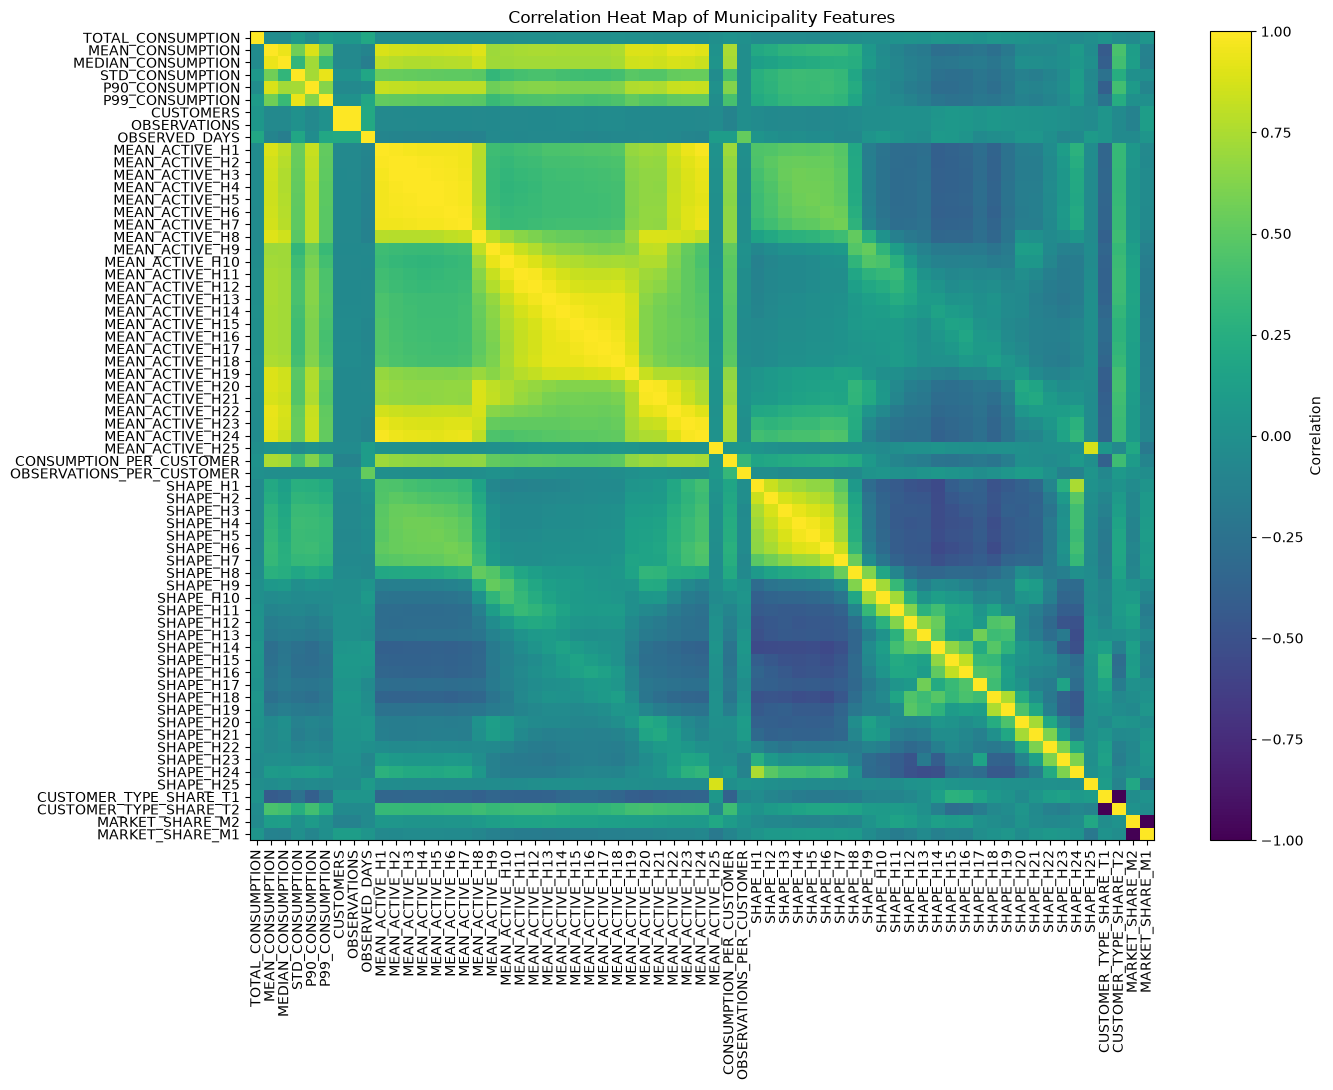

In [74]:
numeric_feature_cols = [
    c for c, dtype in zip(
        municipality_features.columns,
        municipality_features.dtypes
    )
    if c != "MUNICIPALITY" and dtype.is_numeric()
]

corr_df = (
    municipality_features
    .select(numeric_feature_cols)
    .to_pandas()
    .corr()
)

plt.figure(figsize=(14, 11))
plt.imshow(
    corr_df.to_numpy(),
    aspect="auto",
    interpolation="nearest"
)
plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_df.columns)),
    corr_df.columns
)
plt.colorbar(label="Correlation")
plt.title("Correlation Heat Map of Municipality Features")
plt.tight_layout()
plt.show()

The correlation heat map helps identify redundant dimensions. For example, total consumption and customer count are expected to be related, while normalized hourly shape variables describe a different dimension of municipality behaviour.

## Preparing municipality features for clustering

The exploratory analysis shows that municipalities differ in:

- overall consumption;
- consumption intensity;
- customer composition;
- market composition;
- and daily load shape.

The object we want to cluster is therefore the **municipality**, not the individual raw record.

The new feature set is deliberately smaller and more interpretable than the first 65-feature experiment.

In [75]:
municipality_features = (
    A
    .group_by("MUNICIPALITY")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("TOTAL_CONSUMPTION"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("MEAN_CONSUMPTION"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").std().alias("STD_CONSUMPTION"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.len().alias("OBSERVATIONS"),
        pl.col("DATE").n_unique().alias("OBSERVED_DAYS"),
        pl.col("ACTIVE_HOURS_OBSERVED").mean().alias("MEAN_ACTIVE_HOURS_OBSERVED"),
        *[
            pl.col(c).mean().alias(f"MEAN_{c}")
            for c in main_active_cols
        ],
    ])
    .with_columns([
        (
            pl.col("TOTAL_CONSUMPTION") /
            pl.col("CUSTOMERS")
        ).alias("CONSUMPTION_PER_CUSTOMER"),
        (
            pl.col("STD_CONSUMPTION") /
            pl.col("MEAN_CONSUMPTION").replace(0, None)
        ).alias("COEFFICIENT_OF_VARIATION"),
    ])
    .collect()
)

print("Municipalities:", municipality_features.height)
municipality_features.head()

Municipalities: 808


MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,STD_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_HOURS_OBSERVED,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,CONSUMPTION_PER_CUSTOMER,COEFFICIENT_OF_VARIATION
str,i32,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BENIDORM""",665150405,10644.109538,16769.784056,396,62490,353,24.0,341.182877,279.419539,237.24948,211.919923,196.226564,196.757753,219.276412,267.176956,328.490366,444.950248,586.483389,611.820883,630.607073,618.766811,551.3996,526.660426,562.737942,601.236534,614.034982,605.56177,566.058009,539.396239,491.4518,415.243959,1.6797e6,1.575499
"""CEA""",3575204,4786.082999,14112.392524,5,747,337,24.0,118.492637,93.012048,80.354752,68.80589,64.4083,60.702811,64.872825,141.590361,318.111111,329.689424,314.484605,316.515395,256.210174,193.552878,141.350736,126.825971,112.559572,140.599732,203.432396,369.911647,379.523427,373.495315,318.036145,199.544846,715040.8,2.948631
"""BELORADO""",151707,3700.170732,1218.768741,1,41,41,24.0,185.829268,152.536585,147.536585,141.560976,137.536585,142.731707,141.292683,152.097561,166.97561,263.414634,188.682927,127.731707,108.195122,83.268293,86.487805,113.170732,145.0,141.073171,142.414634,147.487805,171.219512,219.658537,170.780488,223.487805,151707.0,0.329382
"""LA TOBA""",485871,1249.025707,2824.488289,2,389,339,24.0,61.156812,47.586118,40.678663,33.966581,31.658098,28.596401,28.789203,31.809769,32.51928,50.411311,63.033419,53.095116,45.742931,47.236504,69.858612,62.573265,57.403599,48.313625,54.894602,54.246787,59.601542,79.498715,91.377892,74.976864,242935.5,2.261353
"""ILLESCAS""",70941523,12702.152731,14974.851889,24,5585,407,24.0,484.313697,399.802865,364.565801,339.189078,321.689705,320.78872,349.948791,443.339839,509.324978,539.961683,570.413787,603.874127,619.057654,640.563115,626.844405,565.075201,554.356132,571.52462,600.068039,636.934467,670.001611,705.205909,670.971352,594.337153,2.9559e6,1.178922


### Normalized hourly load shape

Absolute hourly consumption mainly captures municipality size.

To describe behaviour, we calculate the relative shape of the average daily profile. H1-H24 are used, and one position is omitted from the clustering matrix later because all 24 proportions sum to approximately 1.

In [76]:
mean_hour_cols = [f"MEAN_ACTIVE_H{i}" for i in range(1, 25)]

municipality_features = municipality_features.with_columns(
    pl.sum_horizontal([
        pl.col(c).fill_null(0)
        for c in mean_hour_cols
    ]).alias("_MEAN_PROFILE_TOTAL")
)

municipality_features = municipality_features.with_columns([
    (
        pl.col(c).fill_null(0) /
        pl.col("_MEAN_PROFILE_TOTAL").replace(0, None)
    ).alias(f"SHAPE_H{i}")
    for i, c in enumerate(mean_hour_cols, start=1)
]).drop("_MEAN_PROFILE_TOTAL")

municipality_features.select([
    "MUNICIPALITY",
    *[f"SHAPE_H{i}" for i in range(1, 25)]
]).head()

MUNICIPALITY,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BENIDORM""",0.032054,0.026251,0.022289,0.01991,0.018435,0.018485,0.020601,0.025101,0.030861,0.041802,0.055099,0.05748,0.059245,0.058132,0.051803,0.049479,0.052868,0.056485,0.057688,0.056892,0.05318,0.050676,0.046171,0.039012
"""CEA""",0.024758,0.019434,0.016789,0.014376,0.013457,0.012683,0.013554,0.029584,0.066466,0.068885,0.065708,0.066132,0.053532,0.040441,0.029534,0.026499,0.023518,0.029377,0.042505,0.077289,0.079297,0.078038,0.06645,0.041693
"""BELORADO""",0.050222,0.041224,0.039873,0.038258,0.03717,0.038574,0.038185,0.041106,0.045126,0.07119,0.050993,0.03452,0.029241,0.022504,0.023374,0.030585,0.039187,0.038126,0.038489,0.03986,0.046273,0.059364,0.046155,0.060399
"""LA TOBA""",0.048964,0.038099,0.032568,0.027194,0.025346,0.022895,0.023049,0.025468,0.026036,0.040361,0.050466,0.042509,0.036623,0.037819,0.05593,0.050098,0.045959,0.038681,0.04395,0.043431,0.047718,0.063649,0.073159,0.060028
"""ILLESCAS""",0.038128,0.031475,0.028701,0.026703,0.025326,0.025255,0.02755,0.034903,0.040098,0.042509,0.044907,0.047541,0.048736,0.050429,0.049349,0.044487,0.043643,0.044994,0.047241,0.050144,0.052747,0.055519,0.052823,0.04679


### Customer-type composition

In [77]:
customer_type_counts = (
    A
    .select(["MUNICIPALITY", "CUSTOMER_TYPE"])
    .group_by(["MUNICIPALITY", "CUSTOMER_TYPE"])
    .agg(pl.len().alias("N"))
    .collect()
)

customer_type_totals = (
    customer_type_counts
    .group_by("MUNICIPALITY")
    .agg(pl.col("N").sum().alias("TOTAL_N"))
)

customer_type_shares = (
    customer_type_counts
    .join(customer_type_totals, on="MUNICIPALITY")
    .with_columns(
        (pl.col("N") / pl.col("TOTAL_N")).alias("SHARE")
    )
)

customer_type_wide = (
    customer_type_shares
    .pivot(
        on="CUSTOMER_TYPE",
        index="MUNICIPALITY",
        values="SHARE",
        aggregate_function="sum",
    )
)

customer_type_wide = customer_type_wide.rename({
    c: f"CUSTOMER_TYPE_SHARE_{c}"
    for c in customer_type_wide.columns
    if c != "MUNICIPALITY"
})

municipality_features = municipality_features.join(
    customer_type_wide,
    on="MUNICIPALITY",
    how="left"
)

municipality_features.head()

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,STD_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_HOURS_OBSERVED,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,CONSUMPTION_PER_CUSTOMER,COEFFICIENT_OF_VARIATION,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24,CUSTOMER_TYPE_SHARE_T1,CUSTOMER_TYPE_SHARE_T2
str,i32,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BENIDORM""",665150405,10644.109538,16769.784056,396,62490,353,24.0,341.182877,279.419539,237.24948,211.919923,196.226564,196.757753,219.276412,267.176956,328.490366,444.950248,586.483389,611.820883,630.607073,618.766811,551.3996,526.660426,562.737942,601.236534,614.034982,605.56177,566.058009,539.396239,491.4518,415.243959,1.6797e6,1.575499,0.032054,0.026251,0.022289,0.01991,0.018435,0.018485,0.020601,0.025101,0.030861,0.041802,0.055099,0.05748,0.059245,0.058132,0.051803,0.049479,0.052868,0.056485,0.057688,0.056892,0.05318,0.050676,0.046171,0.039012,0.665931,0.334069
"""CEA""",3575204,4786.082999,14112.392524,5,747,337,24.0,118.492637,93.012048,80.354752,68.80589,64.4083,60.702811,64.872825,141.590361,318.111111,329.689424,314.484605,316.515395,256.210174,193.552878,141.350736,126.825971,112.559572,140.599732,203.432396,369.911647,379.523427,373.495315,318.036145,199.544846,715040.8,2.948631,0.024758,0.019434,0.016789,0.014376,0.013457,0.012683,0.013554,0.029584,0.066466,0.068885,0.065708,0.066132,0.053532,0.040441,0.029534,0.026499,0.023518,0.029377,0.042505,0.077289,0.079297,0.078038,0.06645,0.041693,1.0,0.0
"""BELORADO""",151707,3700.170732,1218.768741,1,41,41,24.0,185.829268,152.536585,147.536585,141.560976,137.536585,142.731707,141.292683,152.097561,166.97561,263.414634,188.682927,127.731707,108.195122,83.268293,86.487805,113.170732,145.0,141.073171,142.414634,147.487805,171.219512,219.658537,170.780488,223.487805,151707.0,0.329382,0.050222,0.041224,0.039873,0.038258,0.03717,0.038574,0.038185,0.041106,0.045126,0.07119,0.050993,0.03452,0.029241,0.022504,0.023374,0.030585,0.039187,0.038126,0.038489,0.03986,0.046273,0.059364,0.046155,0.060399,1.0,0.0
"""LA TOBA""",485871,1249.025707,2824.488289,2,389,339,24.0,61.156812,47.586118,40.678663,33.966581,31.658098,28.596401,28.789203,31.809769,32.51928,50.411311,63.033419,53.095116,45.742931,47.236504,69.858612,62.573265,57.403599,48.313625,54.894602,54.246787,59.601542,79.498715,91.377892,74.976864,242935.5,2.261353,0.048964,0.038099,0.032568,0.027194,0.025346,0.022895,0.023049,0.025468,0.026036,0.040361,0.050466,0.042509,0.036623,0.037819,0.05593,0.050098,0.045959,0.038681,0.04395,0.043431,0.047718,0.063649,0.073159,0.060028,1.0,0.0
"""ILLESCAS""",70941523,12702.152731,14974.851889,24,5585,407,24.0,484.313697,399.802865,364.565801,339.189078,321.689705,320.78872,349.948791,443.339839,509.324978,539.961683,570.413787,603.874127,619.057654,640.563115,626.844405,565.075201,554.356132,571.52462,600.068039,636.934467,670.001611,705.205909,670.971352,594.337153,2.9559e6,1.178922,0.038128,0.031475,0.028701,0.026703,0.025326,0.025255,0.02755,0.034903,0.040098,0.042509,0.044907,0.047541,0.048736,0.050429,0.049349,0.044487,0.043643,0.044994,0.047241,0.050144,0.052747,0.055519,0.052823,0.04679,0.945568,0.054432


### Market composition

In [78]:
market_counts = (
    A
    .select(["MUNICIPALITY", "MARKET"])
    .group_by(["MUNICIPALITY", "MARKET"])
    .agg(pl.len().alias("N"))
    .collect()
)

market_totals = (
    market_counts
    .group_by("MUNICIPALITY")
    .agg(pl.col("N").sum().alias("TOTAL_N"))
)

market_shares = (
    market_counts
    .join(market_totals, on="MUNICIPALITY")
    .with_columns(
        (pl.col("N") / pl.col("TOTAL_N")).alias("SHARE")
    )
)

market_wide = (
    market_shares
    .pivot(
        on="MARKET",
        index="MUNICIPALITY",
        values="SHARE",
        aggregate_function="sum",
    )
)

market_wide = market_wide.rename({
    c: f"MARKET_SHARE_{c}"
    for c in market_wide.columns
    if c != "MUNICIPALITY"
})

municipality_features = municipality_features.join(
    market_wide,
    on="MUNICIPALITY",
    how="left"
)

municipality_features.head()

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_CONSUMPTION,STD_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,MEAN_ACTIVE_HOURS_OBSERVED,MEAN_ACTIVE_H1,MEAN_ACTIVE_H2,MEAN_ACTIVE_H3,MEAN_ACTIVE_H4,MEAN_ACTIVE_H5,MEAN_ACTIVE_H6,MEAN_ACTIVE_H7,MEAN_ACTIVE_H8,MEAN_ACTIVE_H9,MEAN_ACTIVE_H10,MEAN_ACTIVE_H11,MEAN_ACTIVE_H12,MEAN_ACTIVE_H13,MEAN_ACTIVE_H14,MEAN_ACTIVE_H15,MEAN_ACTIVE_H16,MEAN_ACTIVE_H17,MEAN_ACTIVE_H18,MEAN_ACTIVE_H19,MEAN_ACTIVE_H20,MEAN_ACTIVE_H21,MEAN_ACTIVE_H22,MEAN_ACTIVE_H23,MEAN_ACTIVE_H24,CONSUMPTION_PER_CUSTOMER,COEFFICIENT_OF_VARIATION,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,SHAPE_H24,CUSTOMER_TYPE_SHARE_T1,CUSTOMER_TYPE_SHARE_T2,MARKET_SHARE_M1,MARKET_SHARE_M2
str,i32,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BENIDORM""",665150405,10644.109538,16769.784056,396,62490,353,24.0,341.182877,279.419539,237.24948,211.919923,196.226564,196.757753,219.276412,267.176956,328.490366,444.950248,586.483389,611.820883,630.607073,618.766811,551.3996,526.660426,562.737942,601.236534,614.034982,605.56177,566.058009,539.396239,491.4518,415.243959,1.6797e6,1.575499,0.032054,0.026251,0.022289,0.01991,0.018435,0.018485,0.020601,0.025101,0.030861,0.041802,0.055099,0.05748,0.059245,0.058132,0.051803,0.049479,0.052868,0.056485,0.057688,0.056892,0.05318,0.050676,0.046171,0.039012,0.665931,0.334069,0.007617,0.992383
"""CEA""",3575204,4786.082999,14112.392524,5,747,337,24.0,118.492637,93.012048,80.354752,68.80589,64.4083,60.702811,64.872825,141.590361,318.111111,329.689424,314.484605,316.515395,256.210174,193.552878,141.350736,126.825971,112.559572,140.599732,203.432396,369.911647,379.523427,373.495315,318.036145,199.544846,715040.8,2.948631,0.024758,0.019434,0.016789,0.014376,0.013457,0.012683,0.013554,0.029584,0.066466,0.068885,0.065708,0.066132,0.053532,0.040441,0.029534,0.026499,0.023518,0.029377,0.042505,0.077289,0.079297,0.078038,0.06645,0.041693,1.0,0.0,0.0,1.0
"""BELORADO""",151707,3700.170732,1218.768741,1,41,41,24.0,185.829268,152.536585,147.536585,141.560976,137.536585,142.731707,141.292683,152.097561,166.97561,263.414634,188.682927,127.731707,108.195122,83.268293,86.487805,113.170732,145.0,141.073171,142.414634,147.487805,171.219512,219.658537,170.780488,223.487805,151707.0,0.329382,0.050222,0.041224,0.039873,0.038258,0.03717,0.038574,0.038185,0.041106,0.045126,0.07119,0.050993,0.03452,0.029241,0.022504,0.023374,0.030585,0.039187,0.038126,0.038489,0.03986,0.046273,0.059364,0.046155,0.060399,1.0,0.0,0.0,1.0
"""LA TOBA""",485871,1249.025707,2824.488289,2,389,339,24.0,61.156812,47.586118,40.678663,33.966581,31.658098,28.596401,28.789203,31.809769,32.51928,50.411311,63.033419,53.095116,45.742931,47.236504,69.858612,62.573265,57.403599,48.313625,54.894602,54.246787,59.601542,79.498715,91.377892,74.976864,242935.5,2.261353,0.048964,0.038099,0.032568,0.027194,0.025346,0.022895,0.023049,0.025468,0.026036,0.040361,0.050466,0.042509,0.036623,0.037819,0.05593,0.050098,0.045959,0.038681,0.04395,0.043431,0.047718,0.063649,0.073159,0.060028,1.0,0.0,0.0,1.0
"""ILLESCAS""",70941523,12702.152731,14974.851889,24,5585,407,24.0,484.313697,399.802865,364.565801,339.189078,321.689705,320.78872,349.948791,443.339839,509.324978,539.961683,570.413787,603.874127,619.057654,640.563115,626.844405,565.075201,554.356132,571.52462,600.068039,636.934467,670.001611,705.205909,670.971352,594.337153,2.9559e6,1.178922,0.038128,0.031475,0.028701,0.026703,0.025326,0.025255,0.02755,0.034903,0.040098,0.042509,0.044907,0.047541,0.048736,0.050429,0.049349,0.044487,0.043643,0.044994,0.047241,0.050144,0.052747,0.055519,0.052823,0.04679,0.945568,0.054432,0.028827,0.971173


## Choosing a compact clustering feature set

Several variables describe similar information. For example, total consumption, mean consumption and customer count are all related to municipality scale.

Rather than giving K-Means every available summary statistic, the clustering matrix will focus on distinct dimensions:

- municipality scale;
- consumption intensity;
- variability;
- data coverage;
- normalized hourly shape;
- customer-type composition;
- market composition.

The strongly skewed scale variables are log-transformed before standardization.

In [79]:
municipality_features = municipality_features.with_columns([
    pl.col("TOTAL_CONSUMPTION").clip(lower_bound=0).log1p().alias("LOG_TOTAL_CONSUMPTION"),
    pl.col("CUSTOMERS").clip(lower_bound=0).log1p().alias("LOG_CUSTOMERS"),
    pl.col("CONSUMPTION_PER_CUSTOMER").clip(lower_bound=0).log1p().alias("LOG_CONSUMPTION_PER_CUSTOMER"),
])

shape_feature_cols = [f"SHAPE_H{i}" for i in range(1, 24)]

clustering_feature_cols = [
    "LOG_TOTAL_CONSUMPTION",
    "LOG_CUSTOMERS",
    "LOG_CONSUMPTION_PER_CUSTOMER",
    "COEFFICIENT_OF_VARIATION",
    "OBSERVED_DAYS",
    "MEAN_ACTIVE_HOURS_OBSERVED",
    *shape_feature_cols,
    "CUSTOMER_TYPE_SHARE_T2",
    "MARKET_SHARE_M2",
]

print("Number of clustering features:", len(clustering_feature_cols))
print(clustering_feature_cols)

Number of clustering features: 31
['LOG_TOTAL_CONSUMPTION', 'LOG_CUSTOMERS', 'LOG_CONSUMPTION_PER_CUSTOMER', 'COEFFICIENT_OF_VARIATION', 'OBSERVED_DAYS', 'MEAN_ACTIVE_HOURS_OBSERVED', 'SHAPE_H1', 'SHAPE_H2', 'SHAPE_H3', 'SHAPE_H4', 'SHAPE_H5', 'SHAPE_H6', 'SHAPE_H7', 'SHAPE_H8', 'SHAPE_H9', 'SHAPE_H10', 'SHAPE_H11', 'SHAPE_H12', 'SHAPE_H13', 'SHAPE_H14', 'SHAPE_H15', 'SHAPE_H16', 'SHAPE_H17', 'SHAPE_H18', 'SHAPE_H19', 'SHAPE_H20', 'SHAPE_H21', 'SHAPE_H22', 'SHAPE_H23', 'CUSTOMER_TYPE_SHARE_T2', 'MARKET_SHARE_M2']


## Checking the municipality feature table

Before clustering, I check that we still have one row per municipality and identify any missing feature values.

In [80]:
print("Municipality rows:", municipality_features.height)

feature_nulls = (
    municipality_features
    .select(clustering_feature_cols)
    .null_count()
    .transpose(
        include_header=True,
        header_name="column",
        column_names=["null_count"]
    )
    .filter(pl.col("null_count") > 0)
    .sort("null_count", descending=True)
)

feature_nulls

Municipality rows: 808


column,null_count
str,u32
"""COEFFICIENT_OF_VARIATION""",5
"""SHAPE_H1""",5
"""SHAPE_H2""",5
"""SHAPE_H3""",5
"""SHAPE_H4""",5
…,…
"""SHAPE_H19""",5
"""SHAPE_H20""",5
"""SHAPE_H21""",5


Remaining missing feature values will be handled in the clustering matrix using the feature median. This avoids deleting an entire municipality because one derived feature is unavailable.

## Correlation heat map

The correlation heat map is a diagnostic tool. It helps us understand which clustering features are strongly related before applying K-Means.

We do not automatically remove every correlated pair; we use the heat map together with the meaning of the variables to keep the feature set interpretable.

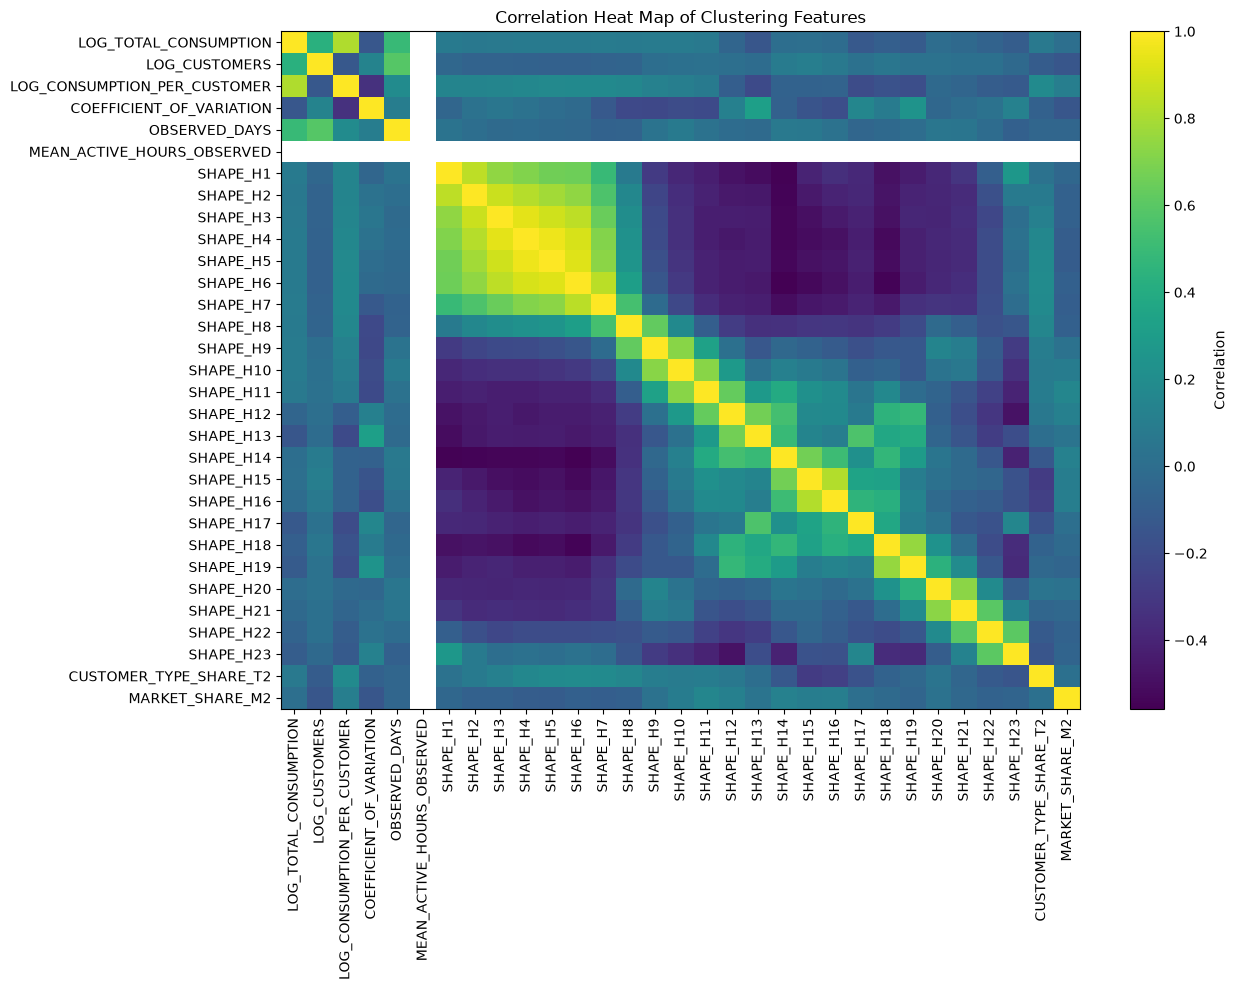

In [81]:
corr_df = (
    municipality_features
    .select(clustering_feature_cols)
    .to_pandas()
    .corr()
)

plt.figure(figsize=(13, 10))
plt.imshow(
    corr_df.to_numpy(),
    aspect="auto",
    interpolation="nearest"
)
plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_df.columns)),
    corr_df.columns
)
plt.colorbar(label="Correlation")
plt.title("Correlation Heat Map of Clustering Features")
plt.tight_layout()
plt.show()

## Preparing the clustering matrix

The municipality name is an identifier, not a numerical feature.

We standardize the numerical features so that a variable measured in large energy units cannot dominate variables such as proportions or standardized load-shape features.

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_df = (
    municipality_features
    .select(["MUNICIPALITY"] + clustering_feature_cols)
    .to_pandas()
)

X_df[clustering_feature_cols] = (
    X_df[clustering_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

X_df[clustering_feature_cols] = (
    X_df[clustering_feature_cols]
    .fillna(X_df[clustering_feature_cols].median())
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    X_df[clustering_feature_cols]
)

print("Municipalities:", X_scaled.shape[0])
print("Clustering features:", X_scaled.shape[1])

Municipalities: 808
Clustering features: 31


## Choosing the number of clusters

The first clustering attempt favoured K=2 and produced a highly unbalanced K=4 solution.

Now that the data has been cleaned and the feature set simplified, we evaluate K again.

No final K is forced in advance.

In [83]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

cluster_evaluation = pl.DataFrame({
    "K": list(k_values),
    "INERTIA": inertias,
    "SILHOUETTE_SCORE": silhouette_scores,
})

cluster_evaluation

K,INERTIA,SILHOUETTE_SCORE
i64,f64,f64
2,20059.43468,0.466409
3,18535.841966,0.482412
4,17155.456993,0.177757
5,16260.066538,0.145664
6,15268.977311,0.141646
7,14295.627194,0.137047
8,13393.130259,0.150626


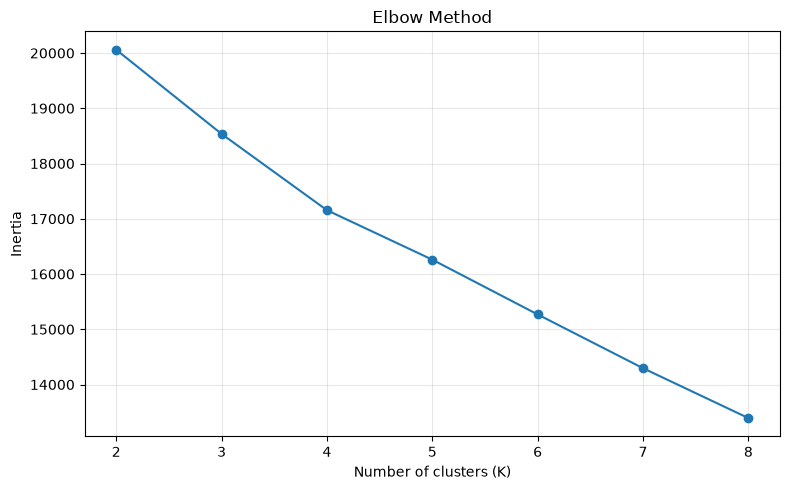

In [84]:
plt.figure(figsize=(8, 5))
plt.plot(
    cluster_evaluation["K"].to_numpy(),
    cluster_evaluation["INERTIA"].to_numpy(),
    marker="o"
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

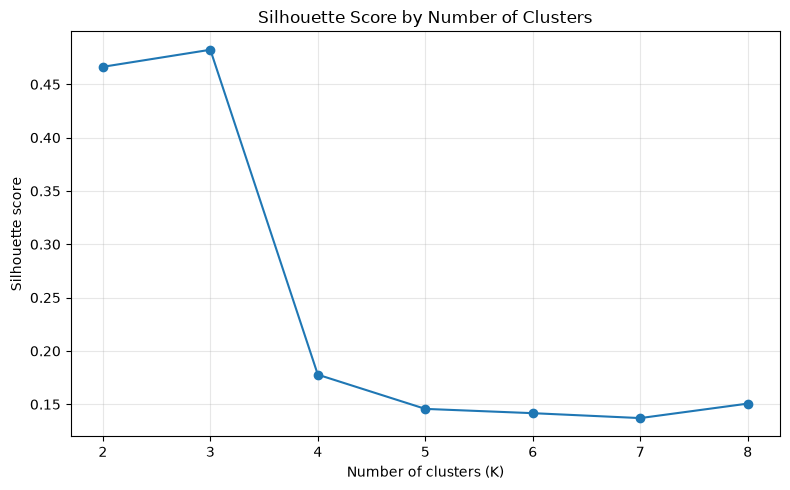

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(
    cluster_evaluation["K"].to_numpy(),
    cluster_evaluation["SILHOUETTE_SCORE"].to_numpy(),
    marker="o"
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Selecting and interpreting the final clusters

The strongest silhouette score is used as the starting point for the final K.

We then inspect cluster sizes and profiles. A numerical score alone is not enough: a useful clustering should also produce groups that can be interpreted and described.

In [86]:
best_k_row = (
    cluster_evaluation
    .sort("SILHOUETTE_SCORE", descending=True)
    .row(0)
)

FINAL_K = int(best_k_row[0])

print("Selected K based on highest silhouette score:", FINAL_K)
print("Silhouette score:", best_k_row[2])

Selected K based on highest silhouette score: 3
Silhouette score: 0.4824118808233171


In [87]:
final_model = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

final_labels = final_model.fit_predict(X_scaled)

clustered_municipalities = X_df.copy()
clustered_municipalities["CLUSTER"] = final_labels

cluster_sizes = (
    pl.from_pandas(clustered_municipalities)
    .group_by("CLUSTER")
    .agg(
        pl.len().alias("MUNICIPALITIES")
    )
    .sort("CLUSTER")
    .with_columns(
        (
            pl.col("MUNICIPALITIES") /
            municipality_features.height * 100
        ).alias("PERCENT_OF_MUNICIPALITIES")
    )
)

cluster_sizes

CLUSTER,MUNICIPALITIES,PERCENT_OF_MUNICIPALITIES
i32,u32,f64
0,723,89.480198
1,51,6.311881
2,34,4.207921


### Why cluster size matters

A cluster containing almost all municipalities and another containing only a handful of extreme municipalities may be mathematically separated but less useful as a general classification.

The final interpretation therefore considers:

- silhouette score;
- elbow behaviour;
- cluster size;
- and the actual municipality profiles.

In [88]:
cluster_profile = (
    pl.from_pandas(clustered_municipalities)
    .group_by("CLUSTER")
    .agg([
        pl.col(c).mean().alias(c)
        for c in clustering_feature_cols
    ])
    .sort("CLUSTER")
)

cluster_profile

CLUSTER,LOG_TOTAL_CONSUMPTION,LOG_CUSTOMERS,LOG_CONSUMPTION_PER_CUSTOMER,COEFFICIENT_OF_VARIATION,OBSERVED_DAYS,MEAN_ACTIVE_HOURS_OBSERVED,SHAPE_H1,SHAPE_H2,SHAPE_H3,SHAPE_H4,SHAPE_H5,SHAPE_H6,SHAPE_H7,SHAPE_H8,SHAPE_H9,SHAPE_H10,SHAPE_H11,SHAPE_H12,SHAPE_H13,SHAPE_H14,SHAPE_H15,SHAPE_H16,SHAPE_H17,SHAPE_H18,SHAPE_H19,SHAPE_H20,SHAPE_H21,SHAPE_H22,SHAPE_H23,CUSTOMER_TYPE_SHARE_T2,MARKET_SHARE_M2
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,16.175803,2.53768,13.887846,1.091307,290.821577,24.0,0.037976,0.030916,0.026942,0.025027,0.024427,0.024543,0.026405,0.032245,0.037997,0.043403,0.047107,0.047159,0.047469,0.049892,0.049307,0.046306,0.043994,0.044236,0.046707,0.050528,0.055335,0.058955,0.055632,0.213037,0.639072
1,15.851049,1.668126,14.52555,1.340637,257.235294,24.0,0.070731,0.070478,0.065185,0.062129,0.060202,0.060725,0.055404,0.041303,0.02565,0.022587,0.022597,0.021331,0.020011,0.018825,0.018778,0.019004,0.019086,0.02102,0.029697,0.036984,0.042486,0.055691,0.068173,0.433243,0.447975
2,5.173696,3.146897,5.068304,2.687157,231.382353,24.0,0.024648,0.021271,0.019873,0.016365,0.015137,0.015175,0.016036,0.021496,0.026043,0.02855,0.036723,0.056835,0.076384,0.050651,0.042359,0.04085,0.060995,0.060189,0.070166,0.066264,0.067071,0.068022,0.059777,0.174846,0.403478


In [89]:
cluster_members = (
    pl.from_pandas(clustered_municipalities)
    .select([
        "MUNICIPALITY",
        "CLUSTER",
        "LOG_TOTAL_CONSUMPTION",
        "LOG_CUSTOMERS",
        "LOG_CONSUMPTION_PER_CUSTOMER",
    ])
    .sort(
        ["CLUSTER", "LOG_TOTAL_CONSUMPTION"],
        descending=[False, True]
    )
)

cluster_members.head(50)

MUNICIPALITY,CLUSTER,LOG_TOTAL_CONSUMPTION,LOG_CUSTOMERS,LOG_CONSUMPTION_PER_CUSTOMER
str,i32,f64,f64,f64
"""SALAMANCA""",0,21.35323,7.333676,14.020207
"""ZARAGOZA""",0,21.308785,7.457032,13.852332
"""BILBAO""",0,21.230703,7.145984,14.085507
"""UBRIQUE""",0,21.223112,7.418781,13.804932
"""ALBACETE""",0,21.194639,6.865891,14.329792
…,…,…,…,…
"""CARTAGENA""",0,19.905485,5.488938,14.420689
"""BADAJOZ""",0,19.817431,5.934894,13.885187
"""EIVISSA""",0,19.773406,5.398163,14.379779


## Final cluster interpretation

The cluster numbers have no intrinsic meaning.

For the final report, each cluster should be described from its observed profile: municipality size, consumption intensity, variability, daily load shape, customer composition and market composition.

Do not label a cluster "industrial", "domestic", "high consumption", or similar unless the feature profile supports that interpretation.

## Saving the analytical results

The raw Table A Parquet file remains untouched.

The following files contain the cleaned and aggregated outputs needed for the report and later analysis.

In [90]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

municipality_totals.write_parquet(
    RESULTS_DIR / "municipality_consumption_ranking.parquet"
)

municipality_features.write_parquet(
    RESULTS_DIR / "municipality_features.parquet"
)

data_cube.write_parquet(
    RESULTS_DIR / "municipality_consumption_data_cube.parquet"
)

pl.from_pandas(clustered_municipalities).write_parquet(
    RESULTS_DIR / "municipality_clusters.parquet"
)

cluster_evaluation.write_parquet(
    RESULTS_DIR / "cluster_evaluation.parquet"
)

print("Results saved to:")
print(RESULTS_DIR)

Results saved to:
e:\tasks\spain_elec\results


## Final conclusions

The analysis now follows a clear evidence-based chain:

**explore → understand → inspect → clean → analyse → engineer municipality features → evaluate clustering → interpret**

The exploratory stage established the structure of Table A and revealed important data-quality characteristics, including substantial hourly missingness, the unusual behaviour of H25, exact duplicate rows, repeated customer-days, and a small number of negative active-energy measurements.

The cleaning stage removes only observations for which there is a clear reason: the missing customer identifier and exact full-row duplicates. The original hourly nulls are preserved.

The municipality analysis answers the first research question by ranking municipalities according to total recorded active electricity consumption, while consumption per represented customer provides a complementary intensity measure.

The heat map and data cube provide temporal and multidimensional context.

Finally, the clustering stage uses a compact municipality-level feature set and evaluates several values of K rather than forcing K=4. The final clusters should be accepted only after considering both the clustering metrics and whether the resulting groups are meaningful and interpretable.